# Yq12 size evolution: BM versus OU with alternative-model diagnostics

## 1. Imports, paths, and settings


In [1]:
from pathlib import Path
import copy
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.stats import chi2, t as student_t
from Bio import Phylo
from IPython.display import display

DATA_PATH = Path(
    "/Users/markloftus/Desktop/UCONN/PersonalProjects/"
    "yq12Estimator/FinalYq12_SRKmer_Estimations.csv"
)

FATHER_SON_PATH = Path(
    "/Users/markloftus/Desktop/UCONN/PersonalProjects/"
    "yq12Estimator/fatherSon_Yq12.csv"
)

TREE_PATH = Path(
    "/Users/markloftus/Desktop/UCONN/PersonalProjects/yq12Estimator/"
    "RAxML_bestTree.bcft_1600_1K_Poznikb38_270521_SG5_woInd_"
    "AD15_DP3_wo2_miss3_VAR_CONC_wo7.nwk"
)

OUTPUT_DIR = Path(
    "Yq12_size_constraint_BM_OU_results"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ROOTING_MODE = "outgroup"
OUTGROUP_SAMPLE = "HG01890"

OUTGROUP_BRANCH_FRACTION = 0.5
N_PRIMARY_NULL_SIM = 100_000
N_FULL_BOOT = 10_000
N_SENSITIVITY_SIM = 10_000
SIM_BATCH_SIZE = 1_000

LAMBDA_PROFILE_GRID_SIZE = 5_001

RANDOM_SEED = 20260828
N_OU_PARAMETRIC_BOOTSTRAP = 500

RUN_MIDPOINT_ROOT_SENSITIVITY = True
RUN_OU_PARAMETRIC_BOOTSTRAP = True

MIN_REGIME_N = 40
MAX_REGIMES = 8
REGIME_GROUP_COLUMN = "YHaploBroad"
MIN_REGIME_MRCA_PURITY = 0.999999
PRIMARY_REGIME_MAPPING = "stem_inclusive"

N_MULTI_REGIME_BOOTSTRAP = 500
RUN_MULTI_REGIME_BOOTSTRAP = True
RUN_MULTI_REGIME_MIDPOINT_SENSITIVITY = True
RUN_SIZE_ADJUSTED_REGIME_SENSITIVITY = True

MIN_EXPECTED_OVERLAP_FRACTION = 0.90

RUN_PAGEL_LAMBDA = True
RUN_DERELATED_SENSITIVITY = True

print(
    "Output directory:",
    OUTPUT_DIR.resolve(),
)


RUN_SIZE_PARAMETRIC_BOOTSTRAP = True
N_SIZE_PARAMETRIC_BOOTSTRAP = 1000
RUN_SIZE_MIDPOINT_ROOT_SENSITIVITY = True
SIZE_RANDOM_SEED = 20260924


Output directory: /Users/markloftus/Desktop/UCONN/anaconda_projects/Yq12_Estimator/Publication/Constraint/Yq12_size_constraint_BM_OU_results


## 2. Load and QC the same 1,597-male SRKmer dataset

In [2]:
df = pd.read_csv(
    DATA_PATH
)

print(
    "Raw shape:",
    df.shape,
)

print(
    "Columns:",
    df.columns.tolist(),
)

d = df.copy()

if (
    "Sample" not in d.columns
    and "Unnamed: 0" in d.columns
):
    d = d.rename(
        columns={
            "Unnamed: 0":
                "Sample"
        }
    )

required_columns = [
    "Sample",
    "Unpolished",
    "DYZ1_Counts",
    "DYZ2_Counts",
    "YHaplo",
    "YHaploBroad",
]

missing = [
    c
    for c in required_columns
    if c not in d.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

d["Sample"] = (
    d["Sample"]
    .astype(str)
    .str.strip()
)

if d["Sample"].duplicated().any():
    duplicated = (
        d.loc[
            d["Sample"].duplicated(
                keep=False
            ),
            "Sample",
        ]
        .tolist()
    )

    raise ValueError(
        "Duplicate sample IDs in population table: "
        + ", ".join(
            duplicated[:20]
        )
    )

n_before = len(d)

d = d.dropna(
    subset=[
        "Unpolished",
        "DYZ1_Counts",
        "DYZ2_Counts",
    ]
).copy()

d = d[
    (
        d["Unpolished"]
        > 0
    )
    &
    (
        d["DYZ1_Counts"]
        > 0
    )
    &
    (
        d["DYZ2_Counts"]
        > 0
    )
].copy()

print(
    "Rows retained after numerical QC:",
    f"{len(d)} / {n_before}",
)


# Derived traits.

d[
    "DYZ1_DYZ2_ratio"
] = (
    d["DYZ1_Counts"]
    /
    d["DYZ2_Counts"]
)

d[
    "log2_DYZ1"
] = np.log2(
    d["DYZ1_Counts"]
)

d[
    "log2_DYZ2"
] = np.log2(
    d["DYZ2_Counts"]
)

d[
    "log2_ratio"
] = (
    d["log2_DYZ1"]
    -
    d["log2_DYZ2"]
)

d[
    "log2_Yq12"
] = np.log2(
    d["Unpolished"]
)

d[
    "Yq12_Mb"
] = (
    d["Unpolished"]
    /
    1e6
)

# Shared DYZ1/DYZ2 expansion-contraction axis.
d[
    "size_axis"
] = (
    d["log2_DYZ1"]
    +
    d["log2_DYZ2"]
) / np.sqrt(
    2
)

# Relative DYZ1/DYZ2 imbalance axis.
d[
    "imbalance_axis"
] = (
    d["log2_DYZ1"]
    -
    d["log2_DYZ2"]
) / np.sqrt(
    2
)


if "Ratio" in d.columns:

    ratio_match = np.allclose(
        d["Ratio"].to_numpy(
            dtype=float
        ),
        d[
            "DYZ1_DYZ2_ratio"
        ].to_numpy(
            dtype=float
        ),
        rtol=1e-6,
        atol=1e-10,
        equal_nan=True,
    )

    print(
        "Stored Ratio == recalculated DYZ1/DYZ2:",
        ratio_match,
    )

    if not ratio_match:
        raise ValueError(
            "Stored Ratio does not match "
            "DYZ1_Counts / DYZ2_Counts."
        )


population_summary = pd.Series({
    "N":
        len(d),
    "Yq12_Mb_min":
        d["Yq12_Mb"].min(),
    "Yq12_Mb_median":
        d["Yq12_Mb"].median(),
    "Yq12_Mb_mean":
        d["Yq12_Mb"].mean(),
    "Yq12_Mb_max":
        d["Yq12_Mb"].max(),
    "DYZ1_DYZ2_ratio_median":
        d["DYZ1_DYZ2_ratio"].median(),
    "DYZ1_DYZ2_ratio_mean":
        d["DYZ1_DYZ2_ratio"].mean(),
    "Pearson_r_log2_DYZ1_log2_DYZ2":
        d["log2_DYZ1"].corr(
            d["log2_DYZ2"],
            method="pearson",
        ),
})

display(
    population_summary
    .to_frame(
        "value"
    )
)


Raw shape: (1597, 8)
Columns: ['Unnamed: 0', 'Polished', 'Unpolished', 'DYZ1_Counts', 'DYZ2_Counts', 'YHaplo', 'YHaploBroad', 'Ratio']
Rows retained after numerical QC: 1597 / 1597
Stored Ratio == recalculated DYZ1/DYZ2: True


,value
N,1597.000000
Yq12_Mb_min,0.931450
Yq12_Mb_median,25.479107
Yq12_Mb_mean,26.507963
Yq12_Mb_max,52.107356
DYZ1_DYZ2_ratio_median,0.944386
DYZ1_DYZ2_ratio_mean,0.963378
Pearson_r_log2_DYZ1_log2_DYZ2,0.866338


## 3. Load, normalize, root, and prune the Y phylogeny


In [3]:
SAMPLE_ID_RE = re.compile(
    r"(?:HG|NA)\d{5}",
    re.IGNORECASE,
)


def normalize_1kg_sample_name(
    value,
):
    value = str(
        value
    ).strip()

    match = SAMPLE_ID_RE.search(
        value
    )

    if match is None:
        return value

    sample = match.group(
        0
    ).upper()

    return sample


tree_original = Phylo.read(
    str(
        TREE_PATH
    ),
    "newick",
)

raw_tip_names = [
    tip.name
    for tip in tree_original.get_terminals()
]

print(
    "Raw tree tips:",
    len(
        raw_tip_names
    ),
)

print(
    "Bio.Phylo tree.rooted flag:",
    tree_original.rooted,
)


# Normalize terminal names.

normalization_rows = []

for tip in tree_original.get_terminals():

    original_name = tip.name

    normalized_name = (
        normalize_1kg_sample_name(
            original_name
        )
    )

    normalization_rows.append({
        "original_tip_name":
            original_name,
        "normalized_tip_name":
            normalized_name,
    })

    tip.name = (
        normalized_name
    )

tree_tip_names = [
    tip.name
    for tip in tree_original.get_terminals()
]


if (
    len(
        tree_tip_names
    )
    !=
    len(
        set(
            tree_tip_names
        )
    )
):
    duplicated = (
        pd.Series(
            tree_tip_names
        )
        .value_counts()
    )

    duplicated = (
        duplicated[
            duplicated > 1
        ]
        .index
        .tolist()
    )

    raise ValueError(
        "Tree-tip normalization created duplicate "
        "sample IDs: "
        + ", ".join(
            duplicated[:20]
        )
    )


tip_normalization = pd.DataFrame(
    normalization_rows
)

display(
    tip_normalization.head(
        20
    )
)

tree_rooted = copy.deepcopy(
    tree_original
)


if ROOTING_MODE == "midpoint":

    print(
        "\nROOTING MODE: midpoint"
    )

    print(
        "This is appropriate for exploratory analysis "
        "of an unrooted RAxML tree, but the final "
        "manuscript analysis should use a biologically "
        "justified Y root if available."
    )

    tree_rooted.root_at_midpoint()


elif ROOTING_MODE == "as_is":

    print(
        "\nROOTING MODE: as_is"
    )

    if not tree_rooted.rooted:
        warnings.warn(
            "The supplied Newick tree is not marked as rooted. "
            "Using its current root position may be arbitrary."
        )


elif ROOTING_MODE == "outgroup":

    if OUTGROUP_SAMPLE is None:
        raise ValueError(
            "Set OUTGROUP_SAMPLE when ROOTING_MODE='outgroup'."
        )

    outgroup_name = (
        normalize_1kg_sample_name(
            OUTGROUP_SAMPLE
        )
    )

    terminals = {
        tip.name:
            tip
        for tip
        in tree_rooted.get_terminals()
    }

    if outgroup_name not in terminals:
        raise ValueError(
            f"Outgroup sample {outgroup_name} "
            "is not a tree tip."
        )

    outgroup_tip = terminals[
        outgroup_name
    ]

    original_outgroup_branch_length = float(
        outgroup_tip.branch_length
        if outgroup_tip.branch_length is not None
        else 0.0
    )

    if original_outgroup_branch_length <= 0:
        raise ValueError(
            f"The branch leading to {outgroup_name} has a non-positive "
            "length, so a biologically meaningful root cannot be placed "
            "within that edge without additional information."
        )

    outgroup_branch_length_after_rooting = (
        original_outgroup_branch_length
        *
        OUTGROUP_BRANCH_FRACTION
    )

    tree_rooted.root_with_outgroup(
        outgroup_tip,
        outgroup_branch_length=
            outgroup_branch_length_after_rooting,
    )

    print(
        "\nROOTING MODE: outgroup branch"
    )

    print(
        "Outgroup sample:",
        outgroup_name,
    )

    print(
        "Original HG01890 terminal branch length:",
        original_outgroup_branch_length,
    )

    print(
        "Root placed at fraction of the original basal edge:",
        OUTGROUP_BRANCH_FRACTION,
    )

    print(
        "HG01890 branch length after rooting:",
        outgroup_branch_length_after_rooting,
    )


else:
    raise ValueError(
        "ROOTING_MODE must be 'midpoint', "
        "'as_is', or 'outgroup'."
    )


# ------------------------------------------------------------------
# Overlap and pruning.
# ------------------------------------------------------------------

tree_samples = set(
    tip.name
    for tip
    in tree_rooted.get_terminals()
)

population_samples = set(
    d["Sample"]
)

overlap = sorted(
    population_samples
    &
    tree_samples
)

population_not_tree = sorted(
    population_samples
    -
    tree_samples
)

tree_not_population = sorted(
    tree_samples
    -
    population_samples
)

overlap_fraction = (
    len(
        overlap
    )
    /
    len(
        population_samples
    )
)

overlap_summary = pd.Series({
    "population_N":
        len(
            population_samples
        ),
    "raw_tree_N":
        len(
            tree_samples
        ),
    "overlap_N":
        len(
            overlap
        ),
    "population_overlap_fraction":
        overlap_fraction,
    "population_samples_missing_from_tree":
        len(
            population_not_tree
        ),
    "tree_samples_missing_from_population":
        len(
            tree_not_population
        ),
})

display(
    overlap_summary
    .to_frame(
        "value"
    )
)

print(
    "\nPopulation samples missing from tree:",
    population_not_tree[:50],
)

print(
    "\nTree samples missing from population table:",
    tree_not_population[:50],
)


if (
    overlap_fraction
    <
    MIN_EXPECTED_OVERLAP_FRACTION
):
    raise ValueError(
        f"Only {overlap_fraction:.1%} of the "
        "population dataset overlaps the tree. "
        "Inspect sample naming before continuing."
    )


tree = copy.deepcopy(
    tree_rooted
)

for tip in list(
    tree.get_terminals()
):
    if (
        tip.name
        not in overlap
    ):
        tree.prune(
            tip
        )


pruned_tip_names = [
    tip.name
    for tip
    in tree.get_terminals()
]

if (
    set(
        pruned_tip_names
    )
    !=
    set(
        overlap
    )
):
    raise AssertionError(
        "Pruned tree tips do not match "
        "the overlap sample set."
    )


traits = (
    d[
        d["Sample"].isin(
            overlap
        )
    ]
    .copy()
    .set_index(
        "Sample"
    )
    .loc[
        pruned_tip_names
    ]
)


print(
    "\nFinal phylogenetic analysis N:",
    len(
        traits
    ),
)

print(
    "Pruned tree tips:",
    len(
        tree.get_terminals()
    ),
)


tip_normalization.to_csv(
    OUTPUT_DIR
    /
    "tree_tip_normalization.csv",
    index=False,
)

pd.DataFrame({
    "Sample":
        population_not_tree
}).to_csv(
    OUTPUT_DIR
    /
    "population_samples_missing_from_tree.csv",
    index=False,
)

pd.DataFrame({
    "Sample":
        tree_not_population
}).to_csv(
    OUTPUT_DIR
    /
    "tree_samples_missing_from_population.csv",
    index=False,
)

Phylo.write(
    tree,
    OUTPUT_DIR
    /
    "Yq12_population_pruned_tree.nwk",
    "newick",
)

traits.to_csv(
    OUTPUT_DIR
    /
    "Yq12_population_phylogenetic_traits.csv"
)

Raw tree tips: 1591
Bio.Phylo tree.rooted flag: False


,original_tip_name,normalized_tip_name
0,HG01890,HG01890
1,HG02984,HG02984
2,HG02982,HG02982
3,HG02613,HG02613
4,HG02666,HG02666
5,HG02668,HG02668
6,HG02645,HG02645
7,HG02647,HG02647
8,HG02590,HG02590
9,HG02588,HG02588



ROOTING MODE: outgroup branch
Outgroup sample: HG01890
Original HG01890 terminal branch length: 0.0077411236349216594
Root placed at fraction of the original basal edge: 0.5
HG01890 branch length after rooting: 0.0038705618174608297


,value
population_N,1597.000000
raw_tree_N,1591.000000
overlap_N,1590.000000
population_overlap_fraction,0.995617
population_samples_missing_from_tree,7.000000
tree_samples_missing_from_population,1.000000



Population samples missing from tree: ['HG01982', 'HG01984', 'HG02966', 'HG03006', 'HG03008', 'HG03976', 'HG03998']

Tree samples missing from population table: ['HG01392']

Final phylogenetic analysis N: 1590
Pruned tree tips: 1590


## 4. Tree and branch-length diagnostics


,value
N_tips,1590
N_internal_nodes,1589
N_nonbinary_internal_nodes,0
N_zero_length_branches,0
minimum_positive_branch_length,0.000001
median_positive_branch_length,0.000101
mean_root_to_tip_distance,0.033844
SD_root_to_tip_distance,0.001116
minimum_root_to_tip_distance,0.003871
maximum_root_to_tip_distance,0.034843


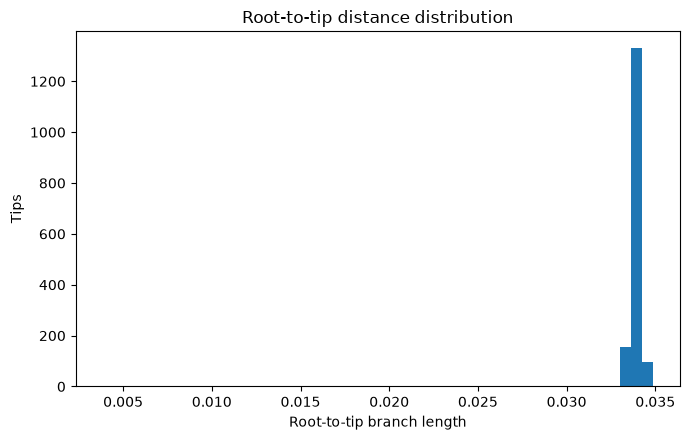

In [4]:
all_nonroot_clades = [
    clade
    for clade
    in tree.find_clades(
        order="preorder"
    )
    if clade is not tree.root
]

missing_branch_lengths = [
    clade
    for clade
    in all_nonroot_clades
    if clade.branch_length is None
]

if missing_branch_lengths:
    raise ValueError(
        f"{len(missing_branch_lengths)} non-root clades "
        "have missing branch lengths."
    )


branch_lengths = np.array([
    float(
        clade.branch_length
    )
    for clade
    in all_nonroot_clades
])

if np.any(
    branch_lengths < 0
):
    raise ValueError(
        "Negative branch lengths are present."
    )


n_zero_branches = int(
    np.sum(
        branch_lengths == 0
    )
)

positive_branch_lengths = (
    branch_lengths[
        branch_lengths > 0
    ]
)


root_to_tip = np.array([
    tree.distance(
        tree.root,
        tip,
    )
    for tip
    in tree.get_terminals()
])


internal_nodes = [
    clade
    for clade
    in tree.find_clades(
        order="preorder"
    )
    if not clade.is_terminal()
]

nonbinary_nodes = [
    clade
    for clade
    in internal_nodes
    if len(
        clade.clades
    ) != 2
]


tree_qc = pd.Series({
    "N_tips":
        len(
            tree.get_terminals()
        ),
    "N_internal_nodes":
        len(
            internal_nodes
        ),
    "N_nonbinary_internal_nodes":
        len(
            nonbinary_nodes
        ),
    "N_zero_length_branches":
        n_zero_branches,
    "minimum_positive_branch_length":
        (
            positive_branch_lengths.min()
            if len(
                positive_branch_lengths
            )
            else np.nan
        ),
    "median_positive_branch_length":
        (
            np.median(
                positive_branch_lengths
            )
            if len(
                positive_branch_lengths
            )
            else np.nan
        ),
    "mean_root_to_tip_distance":
        root_to_tip.mean(),
    "SD_root_to_tip_distance":
        root_to_tip.std(
            ddof=1
        ),
    "minimum_root_to_tip_distance":
        root_to_tip.min(),
    "maximum_root_to_tip_distance":
        root_to_tip.max(),
    "rooting_mode":
        ROOTING_MODE,
})

display(
    tree_qc
    .to_frame(
        "value"
    )
)


fig, ax = plt.subplots(
    figsize=(
        7,
        4.5,
    )
)

ax.hist(
    root_to_tip,
    bins=50,
)

ax.set_xlabel(
    "Root-to-tip branch length"
)

ax.set_ylabel(
    "Tips"
)

ax.set_title(
    "Root-to-tip distance distribution"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    /
    "root_to_tip_distance_distribution.pdf",
    bbox_inches="tight",
)

plt.show()


tree_qc.to_frame(
    "value"
).to_csv(
    OUTPUT_DIR
    /
    "tree_QC_summary.csv"
)

## 5. Rescale the tree for OU fitting

In [5]:
from scipy.optimize import minimize
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import splu

N_RESTORING_NULL_SIM = 20_000

RESTORING_BATCH_SIZE = 250

OU_ALPHA_STARTS = (
    0.01,
    0.1,
    1.0,
    10.0,
)

OU_TIP_RESIDUAL_START_FRACTIONS = (
    0.01,
    0.10,
)

OU_TIME_SCALE = float(
    np.mean(
        root_to_tip
    )
)

if (
    not np.isfinite(
        OU_TIME_SCALE
    )
    or
    OU_TIME_SCALE <= 0
):
    raise ValueError(
        "Mean root-to-tip distance must be positive."
    )


tree_mean_reversion = copy.deepcopy(
    tree
)

for clade in tree_mean_reversion.find_clades(
    order="preorder"
):
    if clade is tree_mean_reversion.root:
        continue

    clade.branch_length = (
        float(
            clade.branch_length
        )
        /
        OU_TIME_SCALE
    )


scaled_root_to_tip = np.array([
    tree_mean_reversion.distance(
        tree_mean_reversion.root,
        tip,
    )
    for tip
    in tree_mean_reversion.get_terminals()
])


mean_reversion_setup = pd.Series({
    "N_tips":
        len(
            traits
        ),
    "rooting_mode":
        ROOTING_MODE,
    "original_mean_root_to_tip":
        OU_TIME_SCALE,
    "scaled_mean_root_to_tip":
        scaled_root_to_tip.mean(),
    "scaled_SD_root_to_tip":
        scaled_root_to_tip.std(
            ddof=1
        ),
    "trait":
        "log2(Yq12 bp)",
    "parity_value":
        np.nan,
})

display(
    mean_reversion_setup
    .to_frame(
        "value"
    )
)

,value
N_tips,1590
rooting_mode,outgroup
original_mean_root_to_tip,0.033844
scaled_mean_root_to_tip,1.0
scaled_SD_root_to_tip,0.032978
trait,log2(Yq12 bp)
parity_value,NaN


## 6. Prepare the Gaussian pruning tree for log2(Yq12)


In [6]:
def prepare_pruning_tree(
    tree,
    trait_series,
):
    """
    Prepare a rooted tree for fast Gaussian pruning.

    Nodes are stored in postorder so all children are evaluated
    before their parent.
    """

    trait_series = pd.Series(
        trait_series
    )

    postorder_nodes = list(
        tree.find_clades(
            order="postorder"
        )
    )

    node_to_index = {
        id(
            node
        ):
            i
        for i, node
        in enumerate(
            postorder_nodes
        )
    }

    n_nodes = len(
        postorder_nodes
    )

    children = [
        []
        for _
        in range(
            n_nodes
        )
    ]

    branch_length = np.zeros(
        n_nodes,
        dtype=float,
    )

    is_tip = np.zeros(
        n_nodes,
        dtype=bool,
    )

    tip_value = np.full(
        n_nodes,
        np.nan,
        dtype=float,
    )


    for i, node in enumerate(
        postorder_nodes
    ):

        is_tip[
            i
        ] = node.is_terminal()

        if (
            node
            is not
            tree.root
        ):
            branch_length[
                i
            ] = float(
                node.branch_length
            )

            if (
                branch_length[
                    i
                ]
                <=
                0
            ):
                raise ValueError(
                    "Mean-reversion likelihood requires "
                    "strictly positive branch lengths."
                )


        if is_tip[
            i
        ]:

            if (
                node.name
                not in
                trait_series.index
            ):
                raise ValueError(
                    f"Missing trait for tip {node.name}"
                )

            tip_value[
                i
            ] = float(
                trait_series.loc[
                    node.name
                ]
            )


        for child in node.clades:

            children[
                i
            ].append(
                node_to_index[
                    id(
                        child
                    )
                ]
            )


    root_index = node_to_index[
        id(
            tree.root
        )
    ]


    return {
        "nodes":
            postorder_nodes,
        "children":
            children,
        "branch_length":
            branch_length,
        "is_tip":
            is_tip,
        "tip_value":
            tip_value,
        "root_index":
            root_index,
    }




size_trait = (
    traits[
        "log2_Yq12"
    ]
    .copy()
)

size_pruning_tree = prepare_pruning_tree(
    tree_mean_reversion,
    size_trait,
)

size_tip_order = [
    tip.name
    for tip in tree_mean_reversion.get_terminals()
]

size_values = (
    size_trait
    .loc[
        size_tip_order
    ]
    .to_numpy(
        dtype=float
    )
)

print(
    "Prepared Yq12-size pruning tree with",
    len(
        size_pruning_tree[
            "nodes"
        ]
    ),
    "total nodes and",
    len(
        size_values
    ),
    "tips."
)


Prepared Yq12-size pruning tree with 3179 total nodes and 1590 tips.


## 7. Gaussian BM / nonstationary OU likelihood


In [7]:
def transform_gaussian_message_to_parent(
    A,
    B,
    C,
    transition_a,
    transition_b,
    transition_variance,
):
    """
    Transform a Gaussian canonical likelihood message through

        x_child = a * x_parent + b + error

    where error ~ N(0, q).

    Input message:
        log L(x_child) =
            -0.5 A x_child^2 + B x_child + C

    Returns the corresponding canonical message in x_parent.
    """

    if (
        A <= 0
        or
        transition_variance <= 0
    ):
        raise ValueError(
            "Gaussian message precision and transition "
            "variance must be positive."
        )


    message_mean = (
        B
        /
        A
    )

    message_variance = (
        1.0
        /
        A
    )


    log_message_integral = (
        C
        +
        B
        *
        B
        /
        (
            2.0
            *
            A
        )
        +
        0.5
        *
        np.log(
            2.0
            *
            np.pi
            /
            A
        )
    )


    combined_variance = (
        transition_variance
        +
        message_variance
    )


    centered_mean = (
        message_mean
        -
        transition_b
    )


    parent_A = (
        transition_a
        *
        transition_a
        /
        combined_variance
    )


    parent_B = (
        transition_a
        *
        centered_mean
        /
        combined_variance
    )


    parent_C = (
        log_message_integral
        -
        0.5
        *
        np.log(
            2.0
            *
            np.pi
            *
            combined_variance
        )
        -
        0.5
        *
        centered_mean
        *
        centered_mean
        /
        combined_variance
    )


    return (
        parent_A,
        parent_B,
        parent_C,
    )


def tree_process_profile_loglik(
    tree_data,
    process_variance,
    tip_residual_variance,
    model,
    alpha=None,
    theta=0.0,
):
    """
    Profile likelihood for BM or OU on a rooted tree.

    The root state is not fixed to theta. It is estimated by
    maximizing the root Gaussian likelihood message.
    """

    if (
        process_variance <= 0
        or
        tip_residual_variance <= 0
    ):
        return {
            "logLik":
                -np.inf,
        }


    if model not in {
        "BM",
        "OU",
    }:
        raise ValueError(
            "model must be 'BM' or 'OU'."
        )


    if model == "OU":

        if (
            alpha is None
            or
            alpha <= 0
        ):
            return {
                "logLik":
                    -np.inf,
            }


    n_nodes = len(
        tree_data[
            "nodes"
        ]
    )


    A = np.zeros(
        n_nodes,
        dtype=float,
    )

    B = np.zeros(
        n_nodes,
        dtype=float,
    )

    C = np.zeros(
        n_nodes,
        dtype=float,
    )


    tip_precision = (
        1.0
        /
        tip_residual_variance
    )


    for i in range(
        n_nodes
    ):

        # Tip observation message:
        # y_i | latent tip state ~ N(x_i, tau^2)
        if tree_data[
            "is_tip"
        ][
            i
        ]:

            y = tree_data[
                "tip_value"
            ][
                i
            ]

            A[
                i
            ] += tip_precision

            B[
                i
            ] += (
                y
                *
                tip_precision
            )

            C[
                i
            ] += -0.5 * (
                y
                *
                y
                *
                tip_precision
                +
                np.log(
                    2.0
                    *
                    np.pi
                    *
                    tip_residual_variance
                )
            )


        for child_index in tree_data[
            "children"
        ][
            i
        ]:

            t = tree_data[
                "branch_length"
            ][
                child_index
            ]


            if model == "BM":

                transition_a = 1.0

                transition_b = 0.0

                transition_variance = (
                    process_variance
                    *
                    t
                )


            else:

                transition_a = np.exp(
                    -alpha
                    *
                    t
                )

                transition_b = (
                    theta
                    *
                    (
                        1.0
                        -
                        transition_a
                    )
                )

                transition_variance = (
                    process_variance
                    *
                    (
                        -np.expm1(
                            -2.0
                            *
                            alpha
                            *
                            t
                        )
                    )
                    /
                    (
                        2.0
                        *
                        alpha
                    )
                )


            transition_variance = max(
                float(
                    transition_variance
                ),
                1e-15,
            )


            transformed = (
                transform_gaussian_message_to_parent(
                    A[
                        child_index
                    ],
                    B[
                        child_index
                    ],
                    C[
                        child_index
                    ],
                    transition_a,
                    transition_b,
                    transition_variance,
                )
            )


            A[
                i
            ] += transformed[
                0
            ]

            B[
                i
            ] += transformed[
                1
            ]

            C[
                i
            ] += transformed[
                2
            ]


    root = tree_data[
        "root_index"
    ]


    if A[
        root
    ] <= 0:
        return {
            "logLik":
                -np.inf,
        }


    root_state_ML = (
        B[
            root
        ]
        /
        A[
            root
        ]
    )


    profile_logLik = (
        C[
            root
        ]
        +
        B[
            root
        ]
        *
        B[
            root
        ]
        /
        (
            2.0
            *
            A[
                root
            ]
        )
    )


    return {
        "logLik":
            float(
                profile_logLik
            ),
        "root_state_ML":
            float(
                root_state_ML
            ),
    }


## 8. Generic BM / nonstationary OU fitting


In [8]:
def fit_mean_reversion_model(
    tree_data,
    y_values,
    model,
    theta_fixed=None,
):
    """
    Multi-start ML fit for:
        BM
        OU with fixed theta
        OU with free theta
    """

    y_values = np.asarray(
        y_values,
        dtype=float,
    )

    trait_variance = float(
        np.var(
            y_values,
            ddof=1,
        )
    )

    trait_SD = float(
        np.std(
            y_values,
            ddof=1,
        )
    )


    if (
        trait_variance <= 0
        or
        not np.isfinite(
            trait_variance
        )
    ):
        raise ValueError(
            "Trait variance must be positive."
        )


    log_sigma_bounds = (
        np.log(
            trait_variance
            *
            1e-4
        ),
        np.log(
            trait_variance
            *
            1e4
        ),
    )


    log_tau_bounds = (
        np.log(
            trait_variance
            *
            1e-8
        ),
        np.log(
            trait_variance
            *
            10.0
        ),
    )


    log_alpha_bounds = (
        np.log(
            1e-4
        ),
        np.log(
            100.0
        ),
    )


    theta_bounds = (
        float(
            y_values.min()
            -
            2.0
            *
            trait_SD
        ),
        float(
            y_values.max()
            +
            2.0
            *
            trait_SD
        ),
    )


    candidates = []


    if model == "BM":

        parameter_names = [
            "log_process_variance",
            "log_tip_residual_variance",
        ]

        bounds = [
            log_sigma_bounds,
            log_tau_bounds,
        ]


        for residual_fraction in (
            0.001,
            0.01,
            0.10,
            0.50,
        ):

            starts = np.array([
                np.log(
                    trait_variance
                ),
                np.log(
                    max(
                        trait_variance
                        *
                        residual_fraction,
                        trait_variance
                        *
                        1e-8,
                    )
                ),
            ])

            candidates.append(
                starts
            )


    elif (
        model == "OU"
        and
        theta_fixed is not None
    ):

        parameter_names = [
            "log_alpha",
            "log_process_variance",
            "log_tip_residual_variance",
        ]

        bounds = [
            log_alpha_bounds,
            log_sigma_bounds,
            log_tau_bounds,
        ]


        for alpha_start in OU_ALPHA_STARTS:

            for residual_fraction in (
                OU_TIP_RESIDUAL_START_FRACTIONS
            ):

                candidates.append(
                    np.array([
                        np.log(
                            alpha_start
                        ),
                        np.log(
                            trait_variance
                        ),
                        np.log(
                            max(
                                trait_variance
                                *
                                residual_fraction,
                                trait_variance
                                *
                                1e-8,
                            )
                        ),
                    ])
                )


    elif (
        model == "OU"
        and
        theta_fixed is None
    ):

        parameter_names = [
            "log_alpha",
            "theta",
            "log_process_variance",
            "log_tip_residual_variance",
        ]

        bounds = [
            log_alpha_bounds,
            theta_bounds,
            log_sigma_bounds,
            log_tau_bounds,
        ]


        theta_starts = sorted(
            set([
                0.0,
                float(
                    np.mean(
                        y_values
                    )
                ),
                float(
                    np.median(
                        y_values
                    )
                ),
            ])
        )


        for alpha_start in OU_ALPHA_STARTS:

            for residual_fraction in (
                OU_TIP_RESIDUAL_START_FRACTIONS
            ):

                for theta_start in theta_starts:

                    theta_start = float(
                        np.clip(
                            theta_start,
                            theta_bounds[
                                0
                            ],
                            theta_bounds[
                                1
                            ],
                        )
                    )


                    candidates.append(
                        np.array([
                            np.log(
                                alpha_start
                            ),
                            theta_start,
                            np.log(
                                trait_variance
                            ),
                            np.log(
                                max(
                                    trait_variance
                                    *
                                    residual_fraction,
                                    trait_variance
                                    *
                                    1e-8,
                                )
                            ),
                        ])
                    )


    else:

        raise ValueError(
            "Unsupported model/theta combination."
        )


    def unpack(
        parameters,
    ):

        if model == "BM":

            return {
                "alpha":
                    None,
                "theta":
                    None,
                "process_variance":
                    np.exp(
                        parameters[
                            0
                        ]
                    ),
                "tip_residual_variance":
                    np.exp(
                        parameters[
                            1
                        ]
                    ),
            }


        if theta_fixed is not None:

            return {
                "alpha":
                    np.exp(
                        parameters[
                            0
                        ]
                    ),
                "theta":
                    float(
                        theta_fixed
                    ),
                "process_variance":
                    np.exp(
                        parameters[
                            1
                        ]
                    ),
                "tip_residual_variance":
                    np.exp(
                        parameters[
                            2
                        ]
                    ),
            }


        return {
            "alpha":
                np.exp(
                    parameters[
                        0
                    ]
                ),
            "theta":
                float(
                    parameters[
                        1
                    ]
                ),
            "process_variance":
                np.exp(
                    parameters[
                        2
                    ]
                ),
            "tip_residual_variance":
                np.exp(
                    parameters[
                        3
                    ]
                ),
        }


    def objective(
        parameters,
    ):

        pars = unpack(
            parameters
        )


        result = tree_process_profile_loglik(
            tree_data,
            process_variance=
                pars[
                    "process_variance"
                ],
            tip_residual_variance=
                pars[
                    "tip_residual_variance"
                ],
            model=model,
            alpha=
                pars[
                    "alpha"
                ],
            theta=(
                0.0
                if pars[
                    "theta"
                ] is None
                else pars[
                    "theta"
                ]
            ),
        )


        if not np.isfinite(
            result[
                "logLik"
            ]
        ):
            return 1e300


        return -result[
            "logLik"
        ]


    optimization_results = []


    for start in candidates:

        result = minimize(
            objective,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter":
                    1_000,
                "ftol":
                    1e-11,
                "gtol":
                    1e-7,
            },
        )

        if (
            result.success
            and
            np.isfinite(
                result.fun
            )
        ):
            optimization_results.append(
                result
            )


    if not optimization_results:
        raise RuntimeError(
            f"No successful optimization for {model}."
        )


    best = min(
        optimization_results,
        key=lambda x:
            x.fun,
    )


    pars = unpack(
        best.x
    )


    likelihood = tree_process_profile_loglik(
        tree_data,
        process_variance=
            pars[
                "process_variance"
            ],
        tip_residual_variance=
            pars[
                "tip_residual_variance"
            ],
        model=model,
        alpha=
            pars[
                "alpha"
            ],
        theta=(
            0.0
            if pars[
                "theta"
            ] is None
            else pars[
                "theta"
            ]
        ),
    )


    if model == "BM":

        n_parameters = 3

    elif theta_fixed is not None:

        n_parameters = 4

    else:

        n_parameters = 5


    output = {
        "model":
            model,
        "theta_mode": (
            "none"
            if model == "BM"
            else (
                "fixed"
                if theta_fixed is not None
                else "free"
            )
        ),
        "theta":
            pars[
                "theta"
            ],
        "alpha":
            pars[
                "alpha"
            ],
        "process_variance":
            pars[
                "process_variance"
            ],
        "tip_residual_variance":
            pars[
                "tip_residual_variance"
            ],
        "root_state_ML":
            likelihood[
                "root_state_ML"
            ],
        "logLik":
            likelihood[
                "logLik"
            ],
        "n_parameters":
            n_parameters,
        "AIC":
            (
                2
                *
                n_parameters
                -
                2
                *
                likelihood[
                    "logLik"
                ]
            ),
        "optimization_success":
            best.success,
        "optimization_message":
            str(
                best.message
            ),
        "n_successful_starts":
            len(
                optimization_results
            ),
        "n_attempted_starts":
            len(
                candidates
            ),
    }


    if model == "OU":

        output[
            "half_life_scaled_root_to_tip_units"
        ] = (
            np.log(
                2.0
            )
            /
            output[
                "alpha"
            ]
        )

        output[
            "half_life_original_tree_units"
        ] = (
            output[
                "half_life_scaled_root_to_tip_units"
            ]
            *
            OU_TIME_SCALE
        )

        output[
            "optimum_DYZ1_DYZ2_ratio"
        ] = (
            2.0
            **
            output[
                "theta"
            ]
        )

        output[
            "stationary_process_variance"
        ] = (
            output[
                "process_variance"
            ]
            /
            (
                2.0
                *
                output[
                    "alpha"
                ]
            )
        )

        output[
            "tip_residual_fraction_of_stationary_plus_tip"
        ] = (
            output[
                "tip_residual_variance"
            ]
            /
            (
                output[
                    "stationary_process_variance"
                ]
                +
                output[
                    "tip_residual_variance"
                ]
            )
        )


    else:

        output[
            "half_life_scaled_root_to_tip_units"
        ] = np.nan

        output[
            "half_life_original_tree_units"
        ] = np.nan

        output[
            "optimum_DYZ1_DYZ2_ratio"
        ] = np.nan

        output[
            "stationary_process_variance"
        ] = np.nan

        output[
            "tip_residual_fraction_of_stationary_plus_tip"
        ] = (
            output[
                "tip_residual_variance"
            ]
            /
            (
                output[
                    "process_variance"
                ]
                +
                output[
                    "tip_residual_variance"
                ]
            )
        )


    return output


## 9. Stationary OU likelihood and fitting


In [9]:
def tree_process_stationary_ou_loglik(
    tree_data,
    process_variance,
    tip_residual_variance,
    alpha,
    theta,
):
    """
    Stationary OU likelihood on a rooted tree.

    Branch transitions follow the standard OU process.
    At the root, instead of profiling a free root state,
    integrate over:

        root ~ N(theta, process_variance / (2 * alpha))
    """

    if (
        process_variance <= 0
        or
        tip_residual_variance <= 0
        or
        alpha <= 0
    ):
        return {
            "logLik":
                -np.inf,
        }


    n_nodes = len(
        tree_data[
            "nodes"
        ]
    )


    A = np.zeros(
        n_nodes,
        dtype=float,
    )

    B = np.zeros(
        n_nodes,
        dtype=float,
    )

    C_message = np.zeros(
        n_nodes,
        dtype=float,
    )


    tip_precision = (
        1.0
        /
        tip_residual_variance
    )


    for i in range(
        n_nodes
    ):

        if tree_data[
            "is_tip"
        ][
            i
        ]:

            y = tree_data[
                "tip_value"
            ][
                i
            ]

            A[
                i
            ] += tip_precision

            B[
                i
            ] += (
                y
                *
                tip_precision
            )

            C_message[
                i
            ] += -0.5 * (
                y
                *
                y
                *
                tip_precision
                +
                np.log(
                    2.0
                    *
                    np.pi
                    *
                    tip_residual_variance
                )
            )


        for child_index in tree_data[
            "children"
        ][
            i
        ]:

            t = tree_data[
                "branch_length"
            ][
                child_index
            ]


            transition_a = np.exp(
                -alpha
                *
                t
            )


            transition_b = (
                theta
                *
                (
                    1.0
                    -
                    transition_a
                )
            )


            transition_variance = (
                process_variance
                *
                (
                    -np.expm1(
                        -2.0
                        *
                        alpha
                        *
                        t
                    )
                )
                /
                (
                    2.0
                    *
                    alpha
                )
            )


            transition_variance = max(
                float(
                    transition_variance
                ),
                1e-15,
            )


            transformed = (
                transform_gaussian_message_to_parent(
                    A[
                        child_index
                    ],
                    B[
                        child_index
                    ],
                    C_message[
                        child_index
                    ],
                    transition_a,
                    transition_b,
                    transition_variance,
                )
            )


            A[
                i
            ] += transformed[
                0
            ]

            B[
                i
            ] += transformed[
                1
            ]

            C_message[
                i
            ] += transformed[
                2
            ]


    root = tree_data[
        "root_index"
    ]


    if A[
        root
    ] <= 0:
        return {
            "logLik":
                -np.inf,
        }


    message_mean = (
        B[
            root
        ]
        /
        A[
            root
        ]
    )


    message_variance = (
        1.0
        /
        A[
            root
        ]
    )


    log_message_integral = (
        C_message[
            root
        ]
        +
        B[
            root
        ]
        *
        B[
            root
        ]
        /
        (
            2.0
            *
            A[
                root
            ]
        )
        +
        0.5
        *
        np.log(
            2.0
            *
            np.pi
            /
            A[
                root
            ]
        )
    )


    stationary_root_variance = (
        process_variance
        /
        (
            2.0
            *
            alpha
        )
    )


    combined_variance = (
        message_variance
        +
        stationary_root_variance
    )


    logLik = (
        log_message_integral
        -
        0.5
        *
        np.log(
            2.0
            *
            np.pi
            *
            combined_variance
        )
        -
        0.5
        *
        (
            message_mean
            -
            theta
        )
        **
        2
        /
        combined_variance
    )


    return {
        "logLik":
            float(
                logLik
            ),

        "posterior_root_message_mean":
            float(
                message_mean
            ),

        "posterior_root_message_variance":
            float(
                message_variance
            ),

        "stationary_root_variance":
            float(
                stationary_root_variance
            ),
    }


In [10]:
def fit_stationary_ou_model(
    tree_data,
    y_values,
    theta_fixed=None,
):
    """
    Multi-start ML fit of stationary OU with either:
        theta fixed, or
        theta estimated freely.
    """

    y_values = np.asarray(
        y_values,
        dtype=float,
    )


    trait_variance = float(
        np.var(
            y_values,
            ddof=1,
        )
    )


    trait_SD = float(
        np.std(
            y_values,
            ddof=1,
        )
    )


    if trait_variance <= 0:
        raise ValueError(
            "Trait variance must be positive."
        )


    log_alpha_bounds = (
        np.log(
            1e-4
        ),
        np.log(
            100.0
        ),
    )


    log_sigma_bounds = (
        np.log(
            trait_variance
            *
            1e-4
        ),
        np.log(
            trait_variance
            *
            1e4
        ),
    )


    log_tau_bounds = (
        np.log(
            trait_variance
            *
            1e-8
        ),
        np.log(
            trait_variance
            *
            10.0
        ),
    )


    theta_bounds = (
        float(
            y_values.min()
            -
            2.0
            *
            trait_SD
        ),
        float(
            y_values.max()
            +
            2.0
            *
            trait_SD
        ),
    )


    candidate_starts = []


    if theta_fixed is not None:

        bounds = [
            log_alpha_bounds,
            log_sigma_bounds,
            log_tau_bounds,
        ]


        for alpha_start in OU_ALPHA_STARTS:

            for residual_fraction in (
                OU_TIP_RESIDUAL_START_FRACTIONS
            ):

                candidate_starts.append(
                    np.array([
                        np.log(
                            alpha_start
                        ),
                        np.log(
                            trait_variance
                        ),
                        np.log(
                            max(
                                trait_variance
                                *
                                residual_fraction,
                                trait_variance
                                *
                                1e-8,
                            )
                        ),
                    ])
                )


    else:

        bounds = [
            log_alpha_bounds,
            theta_bounds,
            log_sigma_bounds,
            log_tau_bounds,
        ]


        theta_starts = sorted(
            set([
                0.0,
                float(
                    np.mean(
                        y_values
                    )
                ),
                float(
                    np.median(
                        y_values
                    )
                ),
            ])
        )


        for alpha_start in OU_ALPHA_STARTS:

            for residual_fraction in (
                OU_TIP_RESIDUAL_START_FRACTIONS
            ):

                for theta_start in theta_starts:

                    theta_start = float(
                        np.clip(
                            theta_start,
                            theta_bounds[
                                0
                            ],
                            theta_bounds[
                                1
                            ],
                        )
                    )


                    candidate_starts.append(
                        np.array([
                            np.log(
                                alpha_start
                            ),
                            theta_start,
                            np.log(
                                trait_variance
                            ),
                            np.log(
                                max(
                                    trait_variance
                                    *
                                    residual_fraction,
                                    trait_variance
                                    *
                                    1e-8,
                                )
                            ),
                        ])
                    )


    def unpack(
        parameters,
    ):

        if theta_fixed is not None:

            return {
                "alpha":
                    np.exp(
                        parameters[
                            0
                        ]
                    ),

                "theta":
                    float(
                        theta_fixed
                    ),

                "process_variance":
                    np.exp(
                        parameters[
                            1
                        ]
                    ),

                "tip_residual_variance":
                    np.exp(
                        parameters[
                            2
                        ]
                    ),
            }


        return {
            "alpha":
                np.exp(
                    parameters[
                        0
                    ]
                ),

            "theta":
                float(
                    parameters[
                        1
                    ]
                ),

            "process_variance":
                np.exp(
                    parameters[
                        2
                    ]
                ),

            "tip_residual_variance":
                np.exp(
                    parameters[
                        3
                    ]
                ),
        }


    def objective(
        parameters,
    ):

        pars = unpack(
            parameters
        )


        result = (
            tree_process_stationary_ou_loglik(
                tree_data,
                process_variance=
                    pars[
                        "process_variance"
                    ],
                tip_residual_variance=
                    pars[
                        "tip_residual_variance"
                    ],
                alpha=
                    pars[
                        "alpha"
                    ],
                theta=
                    pars[
                        "theta"
                    ],
            )
        )


        if not np.isfinite(
            result[
                "logLik"
            ]
        ):
            return 1e300


        return -result[
            "logLik"
        ]


    successful = []


    for start in candidate_starts:

        result = minimize(
            objective,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter":
                    1_000,
                "ftol":
                    1e-11,
                "gtol":
                    1e-7,
            },
        )


        if (
            result.success
            and
            np.isfinite(
                result.fun
            )
        ):
            successful.append(
                result
            )


    if not successful:
        raise RuntimeError(
            "No stationary-OU optimization converged."
        )


    best = min(
        successful,
        key=lambda x:
            x.fun,
    )


    pars = unpack(
        best.x
    )


    likelihood = (
        tree_process_stationary_ou_loglik(
            tree_data,
            process_variance=
                pars[
                    "process_variance"
                ],
            tip_residual_variance=
                pars[
                    "tip_residual_variance"
                ],
            alpha=
                pars[
                    "alpha"
                ],
            theta=
                pars[
                    "theta"
                ],
        )
    )


    n_parameters = (
        3
        if theta_fixed is not None
        else 4
    )


    stationary_variance = (
        pars[
            "process_variance"
        ]
        /
        (
            2.0
            *
            pars[
                "alpha"
            ]
        )
    )


    return {
        "model":
            "OU_stationary",

        "theta_mode": (
            "fixed"
            if theta_fixed is not None
            else "free"
        ),

        "theta":
            pars[
                "theta"
            ],

        "optimum_DYZ1_DYZ2_ratio":
            (
                2.0
                **
                pars[
                    "theta"
                ]
            ),

        "alpha":
            pars[
                "alpha"
            ],

        "half_life_scaled_root_to_tip_units":
            (
                np.log(
                    2.0
                )
                /
                pars[
                    "alpha"
                ]
            ),

        "half_life_original_tree_units":
            (
                np.log(
                    2.0
                )
                /
                pars[
                    "alpha"
                ]
                *
                OU_TIME_SCALE
            ),

        "process_variance":
            pars[
                "process_variance"
            ],

        "stationary_process_variance":
            stationary_variance,

        "tip_residual_variance":
            pars[
                "tip_residual_variance"
            ],

        "tip_residual_fraction_of_stationary_plus_tip":
            (
                pars[
                    "tip_residual_variance"
                ]
                /
                (
                    stationary_variance
                    +
                    pars[
                        "tip_residual_variance"
                    ]
                )
            ),

        "root_state_ML":
            np.nan,

        "stationary_root_SD":
            np.sqrt(
                likelihood[
                    "stationary_root_variance"
                ]
            ),

        "posterior_root_message_mean":
            likelihood[
                "posterior_root_message_mean"
            ],

        "logLik":
            likelihood[
                "logLik"
            ],

        "n_parameters":
            n_parameters,

        "AIC":
            (
                2
                *
                n_parameters
                -
                2
                *
                likelihood[
                    "logLik"
                ]
            ),

        "n_successful_starts":
            len(
                successful
            ),

        "n_attempted_starts":
            len(
                candidate_starts
            ),
    }


## 10. Fit Yq12 size under BM and OU

In [11]:
print("Fitting BM to log2(Yq12)...")

size_bm_fit = fit_mean_reversion_model(
    size_pruning_tree,
    size_values,
    model="BM",
)


print("Fitting nonstationary OU with free optimum to log2(Yq12)...")

size_ou_nonstationary_fit = fit_mean_reversion_model(
    size_pruning_tree,
    size_values,
    model="OU",
    theta_fixed=None,
)


print("Fitting stationary OU with free optimum to log2(Yq12)...")

size_ou_stationary_fit = fit_stationary_ou_model(
    size_pruning_tree,
    size_values,
    theta_fixed=None,
)


def add_size_interpretation(
    fit,
):
    output = dict(
        fit
    )

    if (
        output.get(
            "theta",
            None,
        )
        is not None
        and
        np.isfinite(
            output.get(
                "theta",
                np.nan,
            )
        )
    ):
        output[
            "optimum_Yq12_Mb"
        ] = (
            2.0
            **
            output[
                "theta"
            ]
            /
            1e6
        )

        stationary_var = (
            output[
                "process_variance"
            ]
            /
            (
                2.0
                *
                output[
                    "alpha"
                ]
            )
        )

        latent_sd = np.sqrt(
            stationary_var
        )

        predictive_sd = np.sqrt(
            stationary_var
            +
            output[
                "tip_residual_variance"
            ]
        )

        output[
            "stationary_latent_SD_log2"
        ] = latent_sd

        output[
            "stationary_latent_95pct_lower_Mb"
        ] = (
            2.0
            **
            (
                output[
                    "theta"
                ]
                -
                1.96
                *
                latent_sd
            )
            /
            1e6
        )

        output[
            "stationary_latent_95pct_upper_Mb"
        ] = (
            2.0
            **
            (
                output[
                    "theta"
                ]
                +
                1.96
                *
                latent_sd
            )
            /
            1e6
        )

        output[
            "stationary_predictive_95pct_lower_Mb"
        ] = (
            2.0
            **
            (
                output[
                    "theta"
                ]
                -
                1.96
                *
                predictive_sd
            )
            /
            1e6
        )

        output[
            "stationary_predictive_95pct_upper_Mb"
        ] = (
            2.0
            **
            (
                output[
                    "theta"
                ]
                +
                1.96
                *
                predictive_sd
            )
            /
            1e6
        )

    else:

        output[
            "optimum_Yq12_Mb"
        ] = np.nan

        output[
            "stationary_latent_SD_log2"
        ] = np.nan

        output[
            "stationary_latent_95pct_lower_Mb"
        ] = np.nan

        output[
            "stationary_latent_95pct_upper_Mb"
        ] = np.nan

        output[
            "stationary_predictive_95pct_lower_Mb"
        ] = np.nan

        output[
            "stationary_predictive_95pct_upper_Mb"
        ] = np.nan

    return output


size_bm_fit = add_size_interpretation(
    size_bm_fit
)

size_ou_nonstationary_fit = add_size_interpretation(
    size_ou_nonstationary_fit
)

size_ou_stationary_fit = add_size_interpretation(
    size_ou_stationary_fit
)


size_models = pd.DataFrame([
    size_bm_fit,
    {
        **size_ou_nonstationary_fit,
        "model":
            "OU_nonstationary",
    },
    size_ou_stationary_fit,
])


size_models[
    "Delta_AIC"
] = (
    size_models[
        "AIC"
    ]
    -
    size_models[
        "AIC"
    ].min()
)


size_models[
    "Akaike_weight"
] = np.exp(
    -0.5
    *
    size_models[
        "Delta_AIC"
    ]
)

size_models[
    "Akaike_weight"
] = (
    size_models[
        "Akaike_weight"
    ]
    /
    size_models[
        "Akaike_weight"
    ].sum()
)


size_display_columns = [
    "model",
    "theta_mode",
    "theta",
    "optimum_Yq12_Mb",
    "alpha",
    "half_life_scaled_root_to_tip_units",
    "half_life_original_tree_units",
    "process_variance",
    "tip_residual_variance",
    "tip_residual_fraction_of_stationary_plus_tip",
    "stationary_latent_SD_log2",
    "stationary_latent_95pct_lower_Mb",
    "stationary_latent_95pct_upper_Mb",
    "stationary_predictive_95pct_lower_Mb",
    "stationary_predictive_95pct_upper_Mb",
    "root_state_ML",
    "logLik",
    "n_parameters",
    "AIC",
    "Delta_AIC",
    "Akaike_weight",
]


display(
    size_models.reindex(
        columns=size_display_columns
    )
)


size_models.to_csv(
    OUTPUT_DIR
    /
    "Yq12_size_BM_OU_model_comparison.csv",
    index=False,
)


Fitting BM to log2(Yq12)...
Fitting nonstationary OU with free optimum to log2(Yq12)...
Fitting stationary OU with free optimum to log2(Yq12)...


,model,theta_mode,theta,optimum_Yq12_Mb,alpha,half_life_scaled_root_to_tip_units,half_life_original_tree_units,process_variance,tip_residual_variance,tip_residual_fraction_of_stationary_plus_tip,...,stationary_latent_95pct_lower_Mb,stationary_latent_95pct_upper_Mb,stationary_predictive_95pct_lower_Mb,stationary_predictive_95pct_upper_Mb,root_state_ML,logLik,n_parameters,AIC,Delta_AIC,Akaike_weight
0,BM,none,NaN,NaN,NaN,NaN,NaN,2.612435,0.009178,0.003501,...,NaN,NaN,NaN,NaN,24.208822,117.976742,3,-229.953484,61.667817,2.239299e-14
1,OU_nonstationary,free,24.654469,26.407956,13.537323,0.051203,0.001733,3.749510,0.007915,0.054063,...,15.928154,43.782860,15.702839,44.411088,21.860513,150.810650,5,-291.621300,0.000000,5.509452e-01
2,OU_stationary,free,24.645087,26.236781,13.374932,0.051824,0.001754,3.743579,0.007919,0.053552,...,15.782910,43.614814,15.560678,44.237705,NaN,149.606160,4,-291.212320,0.408980,4.490548e-01


## 11. Observed concentration of Yq12 sizes

,value
N,1590.000000
median_Yq12_Mb,25.470834
q05_Yq12_Mb,17.885373
q95_Yq12_Mb,39.091201
central90_log2_width,1.128064
central90_fold_width,2.185652
IQR_log2_width,0.366553
IQR_fold_width,1.289269
SD_log2,0.341652
range_log2,3.177558


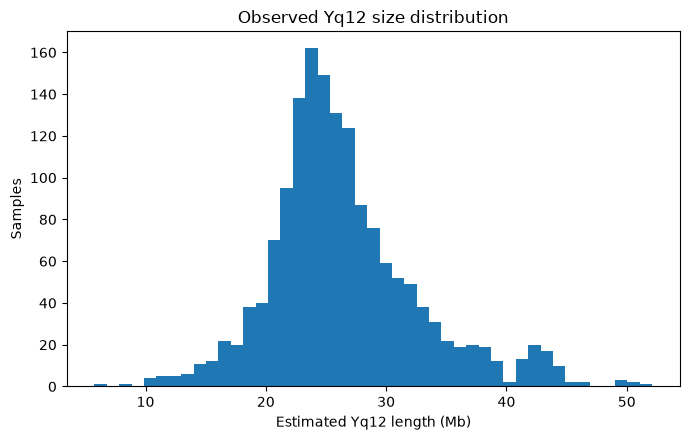

In [12]:
def size_concentration_statistics(
    log2_values,
):
    values = np.asarray(
        log2_values,
        dtype=float,
    )

    q05, q25, q50, q75, q95 = np.quantile(
        values,
        [
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
        ],
    )

    central90 = (
        q95
        -
        q05
    )

    iqr = (
        q75
        -
        q25
    )

    return {
        "N":
            len(
                values
            ),

        "median_Yq12_Mb":
            (
                2.0
                **
                q50
                /
                1e6
            ),

        "q05_Yq12_Mb":
            (
                2.0
                **
                q05
                /
                1e6
            ),

        "q95_Yq12_Mb":
            (
                2.0
                **
                q95
                /
                1e6
            ),

        "central90_log2_width":
            central90,

        "central90_fold_width":
            (
                2.0
                **
                central90
            ),

        "IQR_log2_width":
            iqr,

        "IQR_fold_width":
            (
                2.0
                **
                iqr
            ),

        "SD_log2":
            np.std(
                values,
                ddof=1,
            ),

        "range_log2":
            (
                values.max()
                -
                values.min()
            ),

        "range_fold_width":
            (
                2.0
                **
                (
                    values.max()
                    -
                    values.min()
                )
            ),
    }


observed_size_concentration = pd.Series(
    size_concentration_statistics(
        size_values
    )
)


display(
    observed_size_concentration
    .to_frame(
        "value"
    )
)


fig, ax = plt.subplots(
    figsize=(
        7,
        4.5,
    )
)

ax.hist(
    traits.loc[
        size_tip_order,
        "Yq12_Mb",
    ],
    bins=45,
)

ax.set_xlabel(
    "Estimated Yq12 length (Mb)"
)

ax.set_ylabel(
    "Samples"
)

ax.set_title(
    "Observed Yq12 size distribution"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    /
    "Yq12_size_observed_distribution.pdf",
    bbox_inches="tight",
)

plt.show()


## 12. Parametric bootstrap under the fitted BM null

For each replicate:
1. simulate tip values under the fitted BM + tip-residual model;
2. refit BM, nonstationary OU, and stationary OU;
3. compare the OU advantage with the observed advantage;
4. record the central 90% width of simulated tip values.

In [13]:
def simulate_bm_tip_dataset(
    tree,
    tip_order,
    process_variance,
    tip_residual_variance,
    root_state,
    rng,
):
    """
    Simulate one observed tip dataset under BM + tip residual.
    """

    nodes = list(
        tree.find_clades(
            order="preorder"
        )
    )


    node_to_index = {
        id(
            node
        ):
            i
        for i, node
        in enumerate(
            nodes
        )
    }


    latent = np.empty(
        len(
            nodes
        ),
        dtype=float,
    )


    latent[
        node_to_index[
            id(
                tree.root
            )
        ]
    ] = root_state


    for parent_node in nodes:

        parent_i = node_to_index[
            id(
                parent_node
            )
        ]


        for child_node in parent_node.clades:

            child_i = node_to_index[
                id(
                    child_node
                )
            ]


            t = float(
                child_node.branch_length
            )


            latent[
                child_i
            ] = (
                latent[
                    parent_i
                ]
                +
                np.sqrt(
                    process_variance
                    *
                    t
                )
                *
                rng.standard_normal()
            )


    tip_node_index = {
        node.name:
            node_to_index[
                id(
                    node
                )
            ]
        for node in nodes
        if node.is_terminal()
    }


    tip_latent = np.array([
        latent[
            tip_node_index[
                sample
            ]
        ]
        for sample in tip_order
    ])


    observed = (
        tip_latent
        +
        np.sqrt(
            tip_residual_variance
        )
        *
        rng.standard_normal(
            len(
                tip_order
            )
        )
    )


    return observed


def set_pruning_tip_values(
    tree_data,
    tip_order,
    observed_values,
):
    """
    Return a shallow copy of the pruning structure with
    updated tip observations for a simulated dataset.
    """

    observed_values = np.asarray(
        observed_values,
        dtype=float,
    )


    if (
        len(
            observed_values
        )
        !=
        len(
            tip_order
        )
    ):
        raise ValueError(
            "Observed tip vector has the wrong length."
        )


    output = dict(
        tree_data
    )


    output[
        "tip_value"
    ] = np.array(
        tree_data[
            "tip_value"
        ],
        copy=True,
    )


    name_to_value = {
        sample:
            value
        for sample, value
        in zip(
            tip_order,
            observed_values,
        )
    }


    for i, node in enumerate(
        tree_data[
            "nodes"
        ]
    ):

        if node.is_terminal():

            output[
                "tip_value"
            ][
                i
            ] = name_to_value[
                node.name
            ]


    return output


def fit_bm_warm(
    tree_data,
    y_values,
    start_fit,
):
    """
    Fast warm-start BM fit for parametric bootstrap.
    """

    y_values = np.asarray(
        y_values,
        dtype=float,
    )


    trait_variance = max(
        float(
            np.var(
                y_values,
                ddof=1,
            )
        ),
        1e-8,
    )


    bounds = [
        (
            np.log(
                trait_variance
                *
                1e-5
            ),
            np.log(
                trait_variance
                *
                1e5
            ),
        ),
        (
            np.log(
                trait_variance
                *
                1e-9
            ),
            np.log(
                trait_variance
                *
                10.0
            ),
        ),
    ]


    starts = [
        np.array([
            np.log(
                start_fit[
                    "process_variance"
                ]
            ),
            np.log(
                start_fit[
                    "tip_residual_variance"
                ]
            ),
        ]),

        np.array([
            np.log(
                trait_variance
            ),
            np.log(
                max(
                    trait_variance
                    *
                    0.02,
                    trait_variance
                    *
                    1e-9,
                )
            ),
        ]),
    ]


    def objective(
        pars,
    ):

        result = tree_process_profile_loglik(
            tree_data,
            process_variance=
                np.exp(
                    pars[
                        0
                    ]
                ),
            tip_residual_variance=
                np.exp(
                    pars[
                        1
                    ]
                ),
            model="BM",
        )


        return -result[
            "logLik"
        ]


    results = []


    for start in starts:

        result = minimize(
            objective,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter":
                    400,
                "ftol":
                    1e-9,
            },
        )


        if (
            result.success
            and
            np.isfinite(
                result.fun
            )
        ):
            results.append(
                result
            )


    if not results:
        return None


    best = min(
        results,
        key=lambda x:
            x.fun,
    )


    final = tree_process_profile_loglik(
        tree_data,
        process_variance=
            np.exp(
                best.x[
                    0
                ]
            ),
        tip_residual_variance=
            np.exp(
                best.x[
                    1
                ]
            ),
        model="BM",
    )


    return {
        "logLik":
            final[
                "logLik"
            ],
        "process_variance":
            np.exp(
                best.x[
                    0
                ]
            ),
        "tip_residual_variance":
            np.exp(
                best.x[
                    1
                ]
            ),
        "root_state_ML":
            final[
                "root_state_ML"
            ],
        "AIC":
            (
                2
                *
                3
                -
                2
                *
                final[
                    "logLik"
                ]
            ),
    }


In [14]:
def _size_warm_fit_bounds(
    y_values,
):
    y_values = np.asarray(
        y_values,
        dtype=float,
    )

    trait_variance = max(
        float(
            np.var(
                y_values,
                ddof=1,
            )
        ),
        1e-10,
    )

    trait_sd = max(
        float(
            np.std(
                y_values,
                ddof=1,
            )
        ),
        1e-6,
    )

    return {
        "trait_variance":
            trait_variance,

        "log_alpha_bounds":
            (
                np.log(
                    1e-4
                ),
                np.log(
                    100.0
                ),
            ),

        "theta_bounds":
            (
                float(
                    y_values.min()
                    -
                    2.0
                    *
                    trait_sd
                ),
                float(
                    y_values.max()
                    +
                    2.0
                    *
                    trait_sd
                ),
            ),

        "log_process_bounds":
            (
                np.log(
                    trait_variance
                    *
                    1e-5
                ),
                np.log(
                    trait_variance
                    *
                    1e5
                ),
            ),

        "log_residual_bounds":
            (
                np.log(
                    trait_variance
                    *
                    1e-9
                ),
                np.log(
                    trait_variance
                    *
                    10.0
                ),
            ),
    }


def fit_nonstationary_free_ou_warm(
    tree_data,
    y_values,
    start_fit,
):
    """
    Warm-start free-theta nonstationary OU fit for the BM bootstrap.
    """

    bounds_info = _size_warm_fit_bounds(
        y_values
    )

    bounds = [
        bounds_info[
            "log_alpha_bounds"
        ],
        bounds_info[
            "theta_bounds"
        ],
        bounds_info[
            "log_process_bounds"
        ],
        bounds_info[
            "log_residual_bounds"
        ],
    ]

    theta_low, theta_high = bounds_info[
        "theta_bounds"
    ]

    starts = [
        np.array([
            np.log(
                start_fit[
                    "alpha"
                ]
            ),
            np.clip(
                start_fit[
                    "theta"
                ],
                theta_low,
                theta_high,
            ),
            np.log(
                start_fit[
                    "process_variance"
                ]
            ),
            np.log(
                start_fit[
                    "tip_residual_variance"
                ]
            ),
        ]),

        np.array([
            np.log(
                0.1
            ),
            np.median(
                y_values
            ),
            np.log(
                bounds_info[
                    "trait_variance"
                ]
            ),
            np.log(
                max(
                    bounds_info[
                        "trait_variance"
                    ]
                    *
                    0.02,
                    bounds_info[
                        "trait_variance"
                    ]
                    *
                    1e-9,
                )
            ),
        ]),
    ]


    def objective(
        pars,
    ):

        result = tree_process_profile_loglik(
            tree_data,
            process_variance=
                np.exp(
                    pars[
                        2
                    ]
                ),
            tip_residual_variance=
                np.exp(
                    pars[
                        3
                    ]
                ),
            model="OU",
            alpha=
                np.exp(
                    pars[
                        0
                    ]
                ),
            theta=
                float(
                    pars[
                        1
                    ]
                ),
        )

        return -result[
            "logLik"
        ]


    successful = []

    for start in starts:

        result = minimize(
            objective,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter":
                    500,
                "ftol":
                    1e-9,
            },
        )

        if (
            result.success
            and
            np.isfinite(
                result.fun
            )
        ):
            successful.append(
                result
            )


    if not successful:
        return None


    best = min(
        successful,
        key=lambda x:
            x.fun,
    )


    final = tree_process_profile_loglik(
        tree_data,
        process_variance=
            np.exp(
                best.x[
                    2
                ]
            ),
        tip_residual_variance=
            np.exp(
                best.x[
                    3
                ]
            ),
        model="OU",
        alpha=
            np.exp(
                best.x[
                    0
                ]
            ),
        theta=
            float(
                best.x[
                    1
                ]
            ),
    )


    return {
        "logLik":
            final[
                "logLik"
            ],

        "alpha":
            np.exp(
                best.x[
                    0
                ]
            ),

        "theta":
            float(
                best.x[
                    1
                ]
            ),

        "process_variance":
            np.exp(
                best.x[
                    2
                ]
            ),

        "tip_residual_variance":
            np.exp(
                best.x[
                    3
                ]
            ),

        "root_state_ML":
            final[
                "root_state_ML"
            ],

        "AIC":
            (
                2
                *
                5
                -
                2
                *
                final[
                    "logLik"
                ]
            ),
    }


def fit_stationary_free_ou_warm(
    tree_data,
    y_values,
    start_fit,
):
    """
    Warm-start free-theta stationary OU fit for the BM bootstrap.
    """

    bounds_info = _size_warm_fit_bounds(
        y_values
    )

    bounds = [
        bounds_info[
            "log_alpha_bounds"
        ],
        bounds_info[
            "theta_bounds"
        ],
        bounds_info[
            "log_process_bounds"
        ],
        bounds_info[
            "log_residual_bounds"
        ],
    ]

    theta_low, theta_high = bounds_info[
        "theta_bounds"
    ]

    starts = [
        np.array([
            np.log(
                start_fit[
                    "alpha"
                ]
            ),
            np.clip(
                start_fit[
                    "theta"
                ],
                theta_low,
                theta_high,
            ),
            np.log(
                start_fit[
                    "process_variance"
                ]
            ),
            np.log(
                start_fit[
                    "tip_residual_variance"
                ]
            ),
        ]),

        np.array([
            np.log(
                0.1
            ),
            np.median(
                y_values
            ),
            np.log(
                bounds_info[
                    "trait_variance"
                ]
            ),
            np.log(
                max(
                    bounds_info[
                        "trait_variance"
                    ]
                    *
                    0.02,
                    bounds_info[
                        "trait_variance"
                    ]
                    *
                    1e-9,
                )
            ),
        ]),
    ]


    def objective(
        pars,
    ):

        result = tree_process_stationary_ou_loglik(
            tree_data,
            process_variance=
                np.exp(
                    pars[
                        2
                    ]
                ),
            tip_residual_variance=
                np.exp(
                    pars[
                        3
                    ]
                ),
            alpha=
                np.exp(
                    pars[
                        0
                    ]
                ),
            theta=
                float(
                    pars[
                        1
                    ]
                ),
        )

        return -result[
            "logLik"
        ]


    successful = []

    for start in starts:

        result = minimize(
            objective,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter":
                    500,
                "ftol":
                    1e-9,
            },
        )

        if (
            result.success
            and
            np.isfinite(
                result.fun
            )
        ):
            successful.append(
                result
            )


    if not successful:
        return None


    best = min(
        successful,
        key=lambda x:
            x.fun,
    )


    final = tree_process_stationary_ou_loglik(
        tree_data,
        process_variance=
            np.exp(
                best.x[
                    2
                ]
            ),
        tip_residual_variance=
            np.exp(
                best.x[
                    3
                ]
            ),
        alpha=
            np.exp(
                best.x[
                    0
                ]
            ),
        theta=
            float(
                best.x[
                    1
                ]
            ),
    )


    return {
        "logLik":
            final[
                "logLik"
            ],

        "alpha":
            np.exp(
                best.x[
                    0
                ]
            ),

        "theta":
            float(
                best.x[
                    1
                ]
            ),

        "process_variance":
            np.exp(
                best.x[
                    2
                ]
            ),

        "tip_residual_variance":
            np.exp(
                best.x[
                    3
                ]
            ),

        "AIC":
            (
                2
                *
                4
                -
                2
                *
                final[
                    "logLik"
                ]
            ),
    }


In [15]:
size_bootstrap = pd.DataFrame()
size_bootstrap_summary = pd.Series(
    dtype=float
)


observed_nonstationary_LRT = max(
    0.0,
    2.0
    *
    (
        size_ou_nonstationary_fit[
            "logLik"
        ]
        -
        size_bm_fit[
            "logLik"
        ]
    ),
)


observed_deltaAIC_nonstationary = (
    size_bm_fit[
        "AIC"
    ]
    -
    size_ou_nonstationary_fit[
        "AIC"
    ]
)


observed_deltaAIC_stationary = (
    size_bm_fit[
        "AIC"
    ]
    -
    size_ou_stationary_fit[
        "AIC"
    ]
)


if RUN_SIZE_PARAMETRIC_BOOTSTRAP:

    rng = np.random.default_rng(
        SIZE_RANDOM_SEED
    )

    rows = []


    for replicate in range(
        N_SIZE_PARAMETRIC_BOOTSTRAP
    ):

        simulated_values = simulate_bm_tip_dataset(
            tree_mean_reversion,
            size_tip_order,
            process_variance=
                size_bm_fit[
                    "process_variance"
                ],
            tip_residual_variance=
                size_bm_fit[
                    "tip_residual_variance"
                ],
            root_state=
                size_bm_fit[
                    "root_state_ML"
                ],
            rng=rng,
        )


        simulated_tree_data = set_pruning_tip_values(
            size_pruning_tree,
            size_tip_order,
            simulated_values,
        )


        bm_sim = fit_bm_warm(
            simulated_tree_data,
            simulated_values,
            size_bm_fit,
        )


        ou_nonstat_sim = fit_nonstationary_free_ou_warm(
            simulated_tree_data,
            simulated_values,
            size_ou_nonstationary_fit,
        )


        ou_stat_sim = fit_stationary_free_ou_warm(
            simulated_tree_data,
            simulated_values,
            size_ou_stationary_fit,
        )


        if (
            bm_sim is None
            or
            ou_nonstat_sim is None
            or
            ou_stat_sim is None
        ):

            rows.append({
                "replicate":
                    replicate,
                "fit_success":
                    False,
            })

            continue


        concentration = size_concentration_statistics(
            simulated_values
        )


        rows.append({
            "replicate":
                replicate,

            "fit_success":
                True,

            "BM_logLik":
                bm_sim[
                    "logLik"
                ],

            "OU_nonstationary_logLik":
                ou_nonstat_sim[
                    "logLik"
                ],

            "OU_stationary_logLik":
                ou_stat_sim[
                    "logLik"
                ],

            "LRT_nonstationary_OU_vs_BM":
                max(
                    0.0,
                    2.0
                    *
                    (
                        ou_nonstat_sim[
                            "logLik"
                        ]
                        -
                        bm_sim[
                            "logLik"
                        ]
                    )
                ),

            "DeltaAIC_BM_minus_nonstationary_OU":
                (
                    bm_sim[
                        "AIC"
                    ]
                    -
                    ou_nonstat_sim[
                        "AIC"
                    ]
                ),

            "DeltaAIC_BM_minus_stationary_OU":
                (
                    bm_sim[
                        "AIC"
                    ]
                    -
                    ou_stat_sim[
                        "AIC"
                    ]
                ),

            "central90_log2_width":
                concentration[
                    "central90_log2_width"
                ],

            "central90_fold_width":
                concentration[
                    "central90_fold_width"
                ],

            "SD_log2":
                concentration[
                    "SD_log2"
                ],

            "range_log2":
                concentration[
                    "range_log2"
                ],
        })


    size_bootstrap = pd.DataFrame(
        rows
    )


    successful_size_bootstrap = (
        size_bootstrap[
            size_bootstrap[
                "fit_success"
            ]
            ==
            True
        ]
        .copy()
    )


    if len(
        successful_size_bootstrap
    ) < (
        0.95
        *
        N_SIZE_PARAMETRIC_BOOTSTRAP
    ):

        warnings.warn(
            "Fewer than 95% of Yq12-size bootstrap replicates "
            "converged. Inspect before interpreting."
        )


    def upper_tail_empirical_p(
        simulated,
        observed,
    ):

        simulated = np.asarray(
            simulated,
            dtype=float,
        )

        return (
            1.0
            +
            np.sum(
                simulated
                >=
                observed
            )
        ) / (
            len(
                simulated
            )
            +
            1.0
        )


    def lower_tail_empirical_p(
        simulated,
        observed,
    ):

        simulated = np.asarray(
            simulated,
            dtype=float,
        )

        return (
            1.0
            +
            np.sum(
                simulated
                <=
                observed
            )
        ) / (
            len(
                simulated
            )
            +
            1.0
        )


    size_bootstrap_summary = pd.Series({
        "N_requested":
            N_SIZE_PARAMETRIC_BOOTSTRAP,

        "N_successful":
            len(
                successful_size_bootstrap
            ),

        "observed_LRT_nonstationary_OU_vs_BM":
            observed_nonstationary_LRT,

        "bootstrap_p_LRT_nonstationary_OU_vs_BM":
            upper_tail_empirical_p(
                successful_size_bootstrap[
                    "LRT_nonstationary_OU_vs_BM"
                ],
                observed_nonstationary_LRT,
            ),

        "observed_DeltaAIC_BM_minus_nonstationary_OU":
            observed_deltaAIC_nonstationary,

        "bootstrap_p_nonstationary_DeltaAIC_advantage":
            upper_tail_empirical_p(
                successful_size_bootstrap[
                    "DeltaAIC_BM_minus_nonstationary_OU"
                ],
                observed_deltaAIC_nonstationary,
            ),

        "observed_DeltaAIC_BM_minus_stationary_OU":
            observed_deltaAIC_stationary,

        "bootstrap_p_stationary_DeltaAIC_advantage":
            upper_tail_empirical_p(
                successful_size_bootstrap[
                    "DeltaAIC_BM_minus_stationary_OU"
                ],
                observed_deltaAIC_stationary,
            ),

        "observed_central90_fold_width":
            observed_size_concentration[
                "central90_fold_width"
            ],

        "BM_probability_central90_at_least_as_concentrated":
            lower_tail_empirical_p(
                successful_size_bootstrap[
                    "central90_log2_width"
                ],
                observed_size_concentration[
                    "central90_log2_width"
                ],
            ),

        "observed_SD_log2":
            observed_size_concentration[
                "SD_log2"
            ],

        "BM_probability_SD_at_least_as_small":
            lower_tail_empirical_p(
                successful_size_bootstrap[
                    "SD_log2"
                ],
                observed_size_concentration[
                    "SD_log2"
                ],
            ),
    })


    display(
        size_bootstrap_summary
        .to_frame(
            "value"
        )
    )


    size_bootstrap.to_csv(
        OUTPUT_DIR
        /
        "Yq12_size_BM_parametric_bootstrap.csv",
        index=False,
    )


    size_bootstrap_summary.to_frame(
        "value"
    ).to_csv(
        OUTPUT_DIR
        /
        "Yq12_size_BM_bootstrap_summary.csv"
    )


else:

    print(
        "RUN_SIZE_PARAMETRIC_BOOTSTRAP=False; skipping."
    )


,value
N_requested,1000.000000
N_successful,995.000000
observed_LRT_nonstationary_OU_vs_BM,65.667817
bootstrap_p_LRT_nonstationary_OU_vs_BM,0.001004
observed_DeltaAIC_BM_minus_nonstationary_OU,61.667817
bootstrap_p_nonstationary_DeltaAIC_advantage,0.001004
observed_DeltaAIC_BM_minus_stationary_OU,61.258836
bootstrap_p_stationary_DeltaAIC_advantage,0.001004
observed_central90_fold_width,2.185652
BM_probability_central90_at_least_as_concentrated,0.001004


## 13. Bootstrap diagnostic plots


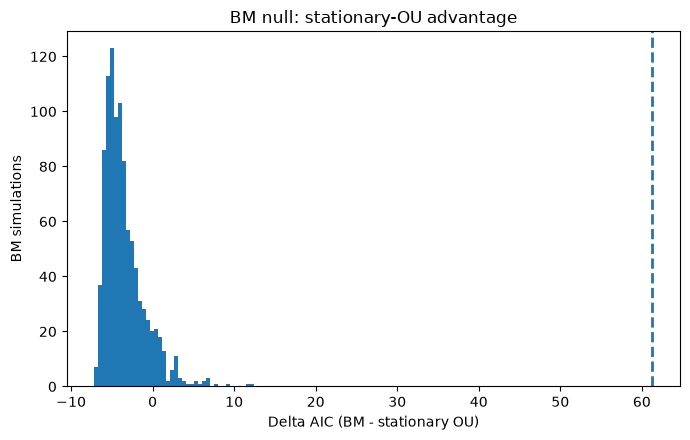

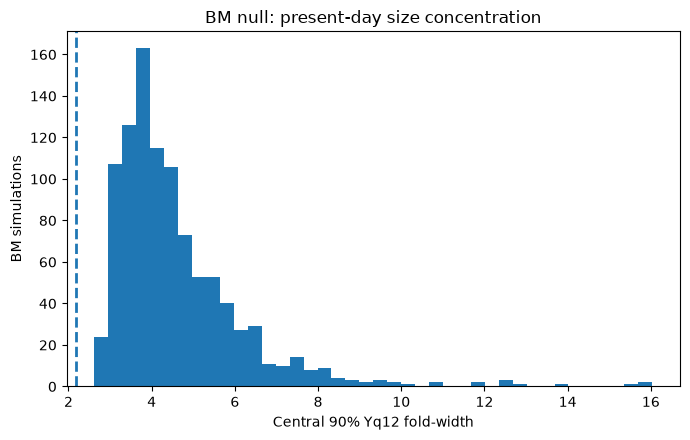

In [16]:
if (
    RUN_SIZE_PARAMETRIC_BOOTSTRAP
    and
    len(
        size_bootstrap
    )
    >
    0
):

    successful_size_bootstrap = (
        size_bootstrap[
            size_bootstrap[
                "fit_success"
            ]
            ==
            True
        ]
        .copy()
    )


    fig, ax = plt.subplots(
        figsize=(
            7,
            4.5,
        )
    )

    ax.hist(
        successful_size_bootstrap[
            "DeltaAIC_BM_minus_stationary_OU"
        ],
        bins=40,
    )

    ax.axvline(
        observed_deltaAIC_stationary,
        linestyle="--",
        linewidth=2,
    )

    ax.set_xlabel(
        "Delta AIC (BM - stationary OU)"
    )

    ax.set_ylabel(
        "BM simulations"
    )

    ax.set_title(
        "BM null: stationary-OU advantage"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        /
        "Yq12_size_BM_bootstrap_stationary_OU_DeltaAIC.pdf",
        bbox_inches="tight",
    )

    plt.show()


    fig, ax = plt.subplots(
        figsize=(
            7,
            4.5,
        )
    )

    ax.hist(
        successful_size_bootstrap[
            "central90_fold_width"
        ],
        bins=40,
    )

    ax.axvline(
        observed_size_concentration[
            "central90_fold_width"
        ],
        linestyle="--",
        linewidth=2,
    )

    ax.set_xlabel(
        "Central 90% Yq12 fold-width"
    )

    ax.set_ylabel(
        "BM simulations"
    )

    ax.set_title(
        "BM null: present-day size concentration"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        /
        "Yq12_size_BM_bootstrap_concentration.pdf",
        bbox_inches="tight",
    )

    plt.show()


## 14. Rooting sensitivity

In [17]:
def build_alternative_pruned_tree(
    tree_original_normalized,
    overlap_samples,
    rooting_mode,
    outgroup_sample=None,
    outgroup_branch_fraction=0.5,
):
    """
    Construct an alternative rooted version of the same tree,
    then prune to the same sample set.
    """

    alternative = copy.deepcopy(
        tree_original_normalized
    )


    if rooting_mode == "midpoint":

        alternative.root_at_midpoint()


    elif rooting_mode == "outgroup":

        if outgroup_sample is None:
            raise ValueError(
                "outgroup_sample is required."
            )


        terminals = {
            tip.name:
                tip
            for tip
            in alternative.get_terminals()
        }


        outgroup_name = (
            normalize_1kg_sample_name(
                outgroup_sample
            )
        )


        if outgroup_name not in terminals:
            raise ValueError(
                f"{outgroup_name} is not present."
            )


        outgroup_tip = terminals[
            outgroup_name
        ]


        original_length = float(
            outgroup_tip.branch_length
            if outgroup_tip.branch_length is not None
            else 0.0
        )


        if original_length <= 0:
            raise ValueError(
                "Outgroup branch must be positive."
            )


        alternative.root_with_outgroup(
            outgroup_tip,
            outgroup_branch_length=
                original_length
                *
                outgroup_branch_fraction,
        )


    else:

        raise ValueError(
            "Unsupported rooting mode."
        )


    for tip in list(
        alternative.get_terminals()
    ):

        if (
            tip.name
            not in overlap_samples
        ):
            alternative.prune(
                tip
            )


    return alternative


def scale_tree_to_mean_root_tip_one(
    tree_input,
):
    scaled = copy.deepcopy(
        tree_input
    )


    distances = np.array([
        scaled.distance(
            scaled.root,
            tip,
        )
        for tip
        in scaled.get_terminals()
    ])


    scale = float(
        distances.mean()
    )


    if scale <= 0:
        raise ValueError(
            "Tree scale must be positive."
        )


    for clade in scaled.find_clades(
        order="preorder"
    ):

        if clade is scaled.root:
            continue


        if (
            clade.branch_length is None
            or
            clade.branch_length <= 0
        ):
            raise ValueError(
                "All branches must be positive after rooting."
            )


        clade.branch_length = (
            float(
                clade.branch_length
            )
            /
            scale
        )


    return (
        scaled,
        scale,
    )


In [18]:
def fit_size_model_set_for_tree(
    tree_input,
    label,
):
    scaled_tree, local_time_scale = (
        scale_tree_to_mean_root_tip_one(
            tree_input
        )
    )


    local_tip_order = [
        tip.name
        for tip
        in scaled_tree.get_terminals()
    ]


    local_trait = (
        size_trait
        .loc[
            local_tip_order
        ]
    )


    local_values = local_trait.to_numpy(
        dtype=float
    )


    local_pruning = prepare_pruning_tree(
        scaled_tree,
        local_trait,
    )


    bm_local = fit_mean_reversion_model(
        local_pruning,
        local_values,
        model="BM",
    )

    global OU_TIME_SCALE

    old_time_scale = OU_TIME_SCALE
    OU_TIME_SCALE = local_time_scale


    try:

        ou_nonstat_local = fit_mean_reversion_model(
            local_pruning,
            local_values,
            model="OU",
            theta_fixed=None,
        )

        ou_stat_local = fit_stationary_ou_model(
            local_pruning,
            local_values,
            theta_fixed=None,
        )

    finally:

        OU_TIME_SCALE = old_time_scale


    return {
        "rooting":
            label,

        "N":
            len(
                local_values
            ),

        "time_scale_original_tree":
            local_time_scale,

        "BM_AIC":
            bm_local[
                "AIC"
            ],

        "OU_nonstationary_AIC":
            ou_nonstat_local[
                "AIC"
            ],

        "OU_stationary_AIC":
            ou_stat_local[
                "AIC"
            ],

        "DeltaAIC_BM_minus_nonstationary_OU":
            (
                bm_local[
                    "AIC"
                ]
                -
                ou_nonstat_local[
                    "AIC"
                ]
            ),

        "DeltaAIC_BM_minus_stationary_OU":
            (
                bm_local[
                    "AIC"
                ]
                -
                ou_stat_local[
                    "AIC"
                ]
            ),

        "nonstationary_optimum_Yq12_Mb":
            (
                2.0
                **
                ou_nonstat_local[
                    "theta"
                ]
                /
                1e6
            ),

        "stationary_optimum_Yq12_Mb":
            (
                2.0
                **
                ou_stat_local[
                    "theta"
                ]
                /
                1e6
            ),

        "nonstationary_alpha":
            ou_nonstat_local[
                "alpha"
            ],

        "stationary_alpha":
            ou_stat_local[
                "alpha"
            ],

        "nonstationary_half_life_scaled":
            ou_nonstat_local[
                "half_life_scaled_root_to_tip_units"
            ],

        "stationary_half_life_scaled":
            ou_stat_local[
                "half_life_scaled_root_to_tip_units"
            ],
    }


# Primary root summary from the already fitted models.
primary_root_summary = {
    "rooting":
        "HG01890_outgroup_edge",

    "N":
        len(
            size_values
        ),

    "time_scale_original_tree":
        OU_TIME_SCALE,

    "BM_AIC":
        size_bm_fit[
            "AIC"
        ],

    "OU_nonstationary_AIC":
        size_ou_nonstationary_fit[
            "AIC"
        ],

    "OU_stationary_AIC":
        size_ou_stationary_fit[
            "AIC"
        ],

    "DeltaAIC_BM_minus_nonstationary_OU":
        observed_deltaAIC_nonstationary,

    "DeltaAIC_BM_minus_stationary_OU":
        observed_deltaAIC_stationary,

    "nonstationary_optimum_Yq12_Mb":
        size_ou_nonstationary_fit[
            "optimum_Yq12_Mb"
        ],

    "stationary_optimum_Yq12_Mb":
        size_ou_stationary_fit[
            "optimum_Yq12_Mb"
        ],

    "nonstationary_alpha":
        size_ou_nonstationary_fit[
            "alpha"
        ],

    "stationary_alpha":
        size_ou_stationary_fit[
            "alpha"
        ],

    "nonstationary_half_life_scaled":
        size_ou_nonstationary_fit[
            "half_life_scaled_root_to_tip_units"
        ],

    "stationary_half_life_scaled":
        size_ou_stationary_fit[
            "half_life_scaled_root_to_tip_units"
        ],
}


root_rows = [
    primary_root_summary
]


if RUN_SIZE_MIDPOINT_ROOT_SENSITIVITY:

    midpoint_tree = build_alternative_pruned_tree(
        tree_original,
        overlap,
        rooting_mode="midpoint",
    )

    midpoint_summary = fit_size_model_set_for_tree(
        midpoint_tree,
        label="midpoint",
    )

    root_rows.append(
        midpoint_summary
    )


size_root_sensitivity = pd.DataFrame(
    root_rows
)


display(
    size_root_sensitivity
)


size_root_sensitivity.to_csv(
    OUTPUT_DIR
    /
    "Yq12_size_root_sensitivity.csv",
    index=False,
)


,rooting,N,time_scale_original_tree,BM_AIC,OU_nonstationary_AIC,OU_stationary_AIC,DeltaAIC_BM_minus_nonstationary_OU,DeltaAIC_BM_minus_stationary_OU,nonstationary_optimum_Yq12_Mb,stationary_optimum_Yq12_Mb,nonstationary_alpha,stationary_alpha,nonstationary_half_life_scaled,stationary_half_life_scaled
0,HG01890_outgroup_edge,1590,0.033844,-229.953484,-291.621300,-291.212320,61.667817,61.258836,26.407956,26.236781,13.537323,13.374932,0.051203,0.051824
1,midpoint,1590,0.018440,-229.413608,-290.297791,-291.212333,60.884184,61.798725,23.776814,26.237319,7.450260,7.288694,0.093037,0.095099


## 15. Compact result table for the Discussion

In [19]:
size_interpretation = pd.Series({
    "N":
        len(
            size_values
        ),

    "observed_Yq12_median_Mb":
        observed_size_concentration[
            "median_Yq12_Mb"
        ],

    "observed_Yq12_q05_Mb":
        observed_size_concentration[
            "q05_Yq12_Mb"
        ],

    "observed_Yq12_q95_Mb":
        observed_size_concentration[
            "q95_Yq12_Mb"
        ],

    "nonstationary_OU_optimum_Mb":
        size_ou_nonstationary_fit[
            "optimum_Yq12_Mb"
        ],

    "stationary_OU_optimum_Mb":
        size_ou_stationary_fit[
            "optimum_Yq12_Mb"
        ],

    "stationary_OU_latent_95pct_lower_Mb":
        size_ou_stationary_fit[
            "stationary_latent_95pct_lower_Mb"
        ],

    "stationary_OU_latent_95pct_upper_Mb":
        size_ou_stationary_fit[
            "stationary_latent_95pct_upper_Mb"
        ],

    "stationary_OU_half_life_mean_tree_depth_units":
        size_ou_stationary_fit[
            "half_life_scaled_root_to_tip_units"
        ],

    "DeltaAIC_BM_minus_nonstationary_OU":
        observed_deltaAIC_nonstationary,

    "DeltaAIC_BM_minus_stationary_OU":
        observed_deltaAIC_stationary,
})


if RUN_SIZE_PARAMETRIC_BOOTSTRAP:

    size_interpretation[
        "bootstrap_p_nonstationary_OU_vs_BM"
    ] = size_bootstrap_summary[
        "bootstrap_p_LRT_nonstationary_OU_vs_BM"
    ]

    size_interpretation[
        "bootstrap_p_stationary_OU_advantage"
    ] = size_bootstrap_summary[
        "bootstrap_p_stationary_DeltaAIC_advantage"
    ]

    size_interpretation[
        "BM_probability_observed_or_tighter_central90_width"
    ] = size_bootstrap_summary[
        "BM_probability_central90_at_least_as_concentrated"
    ]


display(
    size_interpretation
    .to_frame(
        "value"
    )
)


size_interpretation.to_frame(
    "value"
).to_csv(
    OUTPUT_DIR
    /
    "Yq12_size_discussion_summary.csv"
)


observed_size_concentration.to_frame(
    "value"
).to_csv(
    OUTPUT_DIR
    /
    "Yq12_size_observed_concentration.csv"
)


,value
N,1590.000000
observed_Yq12_median_Mb,25.470834
observed_Yq12_q05_Mb,17.885373
observed_Yq12_q95_Mb,39.091201
nonstationary_OU_optimum_Mb,26.407956
stationary_OU_optimum_Mb,26.236781
stationary_OU_latent_95pct_lower_Mb,15.782910
stationary_OU_latent_95pct_upper_Mb,43.614814
stationary_OU_half_life_mean_tree_depth_units,0.051824
DeltaAIC_BM_minus_nonstationary_OU,61.667817


## 17. Branch-length and ultrametricity audit

,value
N_tips,1590
mean_root_to_tip,0.033844
SD_root_to_tip,0.001116
CV_root_to_tip,0.032978
relative_root_to_tip_range,0.915154
min_root_to_tip,0.003871
max_root_to_tip,0.034843
Pearson_r_root_to_tip_vs_log2Yq12,0.013616
Pearson_p_root_to_tip_vs_log2Yq12,0.587459
Spearman_rho_root_to_tip_vs_log2Yq12,-0.100171


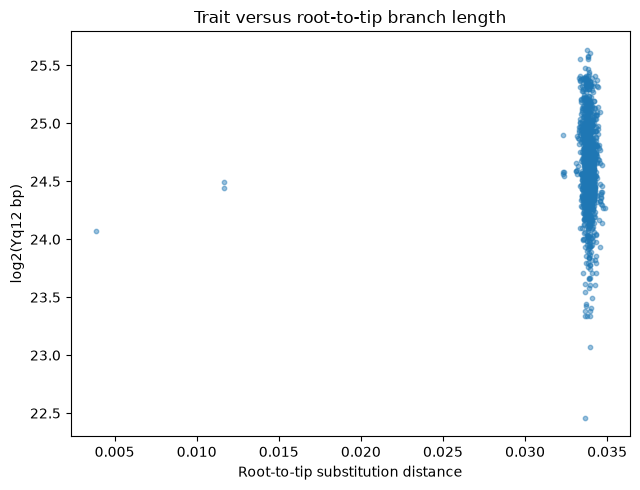

NOTE: A non-zero root-to-tip CV quantifies non-ultrametricity. It does not by itself invalidate the model, but it means raw RAxML branch lengths are not an exact relative-time tree.
NOTE: TREE_PATH contains 'VAR'. Confirm from the original RAxML command/info file whether variable-site ascertainment correction was used before interpreting branch-length-derived alpha biologically.


In [24]:
# Root-to-tip audit on the primary pruned RAxML tree.
primary_tip_names = [tip.name for tip in tree.get_terminals()]
primary_root_to_tip = np.array([
    tree.distance(tree.root, tip)
    for tip in tree.get_terminals()
], dtype=float)
primary_trait_ordered = size_trait.loc[primary_tip_names].to_numpy(dtype=float)

root_tip_mean = float(np.mean(primary_root_to_tip))
root_tip_sd = float(np.std(primary_root_to_tip, ddof=1))
root_tip_cv = root_tip_sd / root_tip_mean
root_tip_relative_range = (
    float(np.max(primary_root_to_tip) - np.min(primary_root_to_tip))
    / root_tip_mean
)

pearson_rt = stats.pearsonr(primary_root_to_tip, primary_trait_ordered)
spearman_rt = stats.spearmanr(primary_root_to_tip, primary_trait_ordered)

branch_length_audit = pd.Series({
    "N_tips": len(primary_tip_names),
    "mean_root_to_tip": root_tip_mean,
    "SD_root_to_tip": root_tip_sd,
    "CV_root_to_tip": root_tip_cv,
    "relative_root_to_tip_range": root_tip_relative_range,
    "min_root_to_tip": float(np.min(primary_root_to_tip)),
    "max_root_to_tip": float(np.max(primary_root_to_tip)),
    "Pearson_r_root_to_tip_vs_log2Yq12": float(pearson_rt.statistic),
    "Pearson_p_root_to_tip_vs_log2Yq12": float(pearson_rt.pvalue),
    "Spearman_rho_root_to_tip_vs_log2Yq12": float(spearman_rt.statistic),
    "Spearman_p_root_to_tip_vs_log2Yq12": float(spearman_rt.pvalue),
    "tree_filename_contains_VAR": "VAR" in TREE_PATH.name.upper(),
})

display(branch_length_audit.to_frame("value"))
branch_length_audit.to_frame("value").to_csv(
    OUTPUT_DIR / "Yq12_branch_length_audit.csv"
)

fig, ax = plt.subplots(figsize=(6.5, 5.0))
ax.scatter(primary_root_to_tip, primary_trait_ordered, s=10, alpha=0.45)
ax.set_xlabel("Root-to-tip substitution distance")
ax.set_ylabel("log2(Yq12 bp)")
ax.set_title("Trait versus root-to-tip branch length")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "Yq12_trait_vs_root_to_tip_distance.pdf",
    bbox_inches="tight",
)
plt.show()

print(
    "NOTE: A non-zero root-to-tip CV quantifies non-ultrametricity. "
    "It does not by itself invalidate the model, but it means raw RAxML "
    "branch lengths are not an exact relative-time tree."
)
if "VAR" in TREE_PATH.name.upper():
    print(
        "NOTE: TREE_PATH contains 'VAR'. Confirm from the original RAxML "
        "command/info file whether variable-site ascertainment correction "
        "was used before interpreting branch-length-derived alpha biologically."
    )


## 18. Profile-likelihood CI for stationary-OU α and half-life

,value
alpha_MLE,13.374932
alpha_profile_CI_low,9.910688
alpha_profile_CI_high,17.030202
CI_level,0.950000
half_life_MLE_scaled_root_to_tip_units,0.051824
half_life_MLE_original_tree_units,0.001754
half_life_profile_CI_low_original_tree_units,0.001378
half_life_profile_CI_high_original_tree_units,0.002367


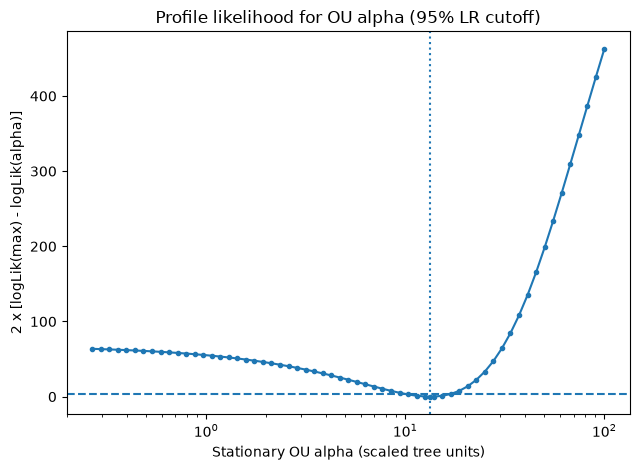

In [25]:
def fit_stationary_ou_at_fixed_alpha(
    tree_data,
    y_values,
    alpha_fixed,
    extra_start=None,
):
    """Optimize theta, process variance and tip variance at fixed alpha."""
    y_values = np.asarray(y_values, dtype=float)
    trait_var = float(np.var(y_values, ddof=1))
    trait_sd = float(np.std(y_values, ddof=1))

    theta_bounds = (
        float(y_values.min() - 2.0 * trait_sd),
        float(y_values.max() + 2.0 * trait_sd),
    )
    log_sigma_bounds = (
        np.log(trait_var * 1e-4),
        np.log(trait_var * 1e4),
    )
    log_tau_bounds = (
        np.log(trait_var * 1e-8),
        np.log(trait_var * 10.0),
    )
    bounds = [theta_bounds, log_sigma_bounds, log_tau_bounds]

    mle_start = np.array([
        size_ou_stationary_fit["theta"],
        np.log(size_ou_stationary_fit["process_variance"]),
        np.log(size_ou_stationary_fit["tip_residual_variance"]),
    ], dtype=float)

    starts = [mle_start]
    if extra_start is not None:
        starts.append(np.asarray(extra_start, dtype=float))

    for residual_fraction in (0.01, 0.10):
        starts.append(np.array([
            float(np.mean(y_values)),
            np.log(trait_var),
            np.log(max(trait_var * residual_fraction, trait_var * 1e-8)),
        ]))

    def objective(par):
        ll = tree_process_stationary_ou_loglik(
            tree_data,
            process_variance=np.exp(par[1]),
            tip_residual_variance=np.exp(par[2]),
            alpha=float(alpha_fixed),
            theta=float(par[0]),
        )["logLik"]
        return 1e300 if not np.isfinite(ll) else -ll

    fits = []
    for start in starts:
        fit = minimize(
            objective,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 1000, "ftol": 1e-11, "gtol": 1e-7},
        )
        if fit.success and np.isfinite(fit.fun):
            fits.append(fit)

    if not fits:
        return None

    best = min(fits, key=lambda x: x.fun)
    return {
        "alpha": float(alpha_fixed),
        "theta": float(best.x[0]),
        "process_variance": float(np.exp(best.x[1])),
        "tip_residual_variance": float(np.exp(best.x[2])),
        "logLik": float(-best.fun),
        "optimizer_x": np.asarray(best.x, dtype=float),
    }


def _profile_crossing(log_alpha, lr, cutoff, side, best_idx):
    """Linear interpolation on log(alpha) at an LR cutoff."""
    if side == "lower":
        inside = np.where((np.arange(len(lr)) <= best_idx) & (lr <= cutoff))[0]
        if len(inside) == 0:
            return np.nan
        i_in = int(inside.min())
        if i_in == 0:
            return np.nan
        i_out = i_in - 1
    else:
        inside = np.where((np.arange(len(lr)) >= best_idx) & (lr <= cutoff))[0]
        if len(inside) == 0:
            return np.nan
        i_in = int(inside.max())
        if i_in == len(lr) - 1:
            return np.nan
        i_out = i_in + 1

    x1, y1 = log_alpha[i_in], lr[i_in] - cutoff
    x2, y2 = log_alpha[i_out], lr[i_out] - cutoff
    if y2 == y1:
        return float(np.exp((x1 + x2) / 2.0))
    x_cross = x1 + (0.0 - y1) * (x2 - x1) / (y2 - y1)
    return float(np.exp(x_cross))


alpha_mle = float(size_ou_stationary_fit["alpha"])
alpha_low_grid = max(1e-4, alpha_mle / PROFILE_ALPHA_FOLD_RANGE)
alpha_high_grid = min(100.0, alpha_mle * PROFILE_ALPHA_FOLD_RANGE)

alpha_grid = np.unique(np.sort(np.r_[
    np.logspace(
        np.log10(alpha_low_grid),
        np.log10(alpha_high_grid),
        PROFILE_ALPHA_GRID_N,
    ),
    alpha_mle,
]))

profile_rows = []
previous_start = None
for alpha_value in alpha_grid:
    fit = fit_stationary_ou_at_fixed_alpha(
        size_pruning_tree,
        size_values,
        alpha_value,
        extra_start=previous_start,
    )
    if fit is None:
        profile_rows.append({"alpha": alpha_value, "logLik": np.nan})
        continue
    profile_rows.append({
        "alpha": fit["alpha"],
        "theta": fit["theta"],
        "process_variance": fit["process_variance"],
        "tip_residual_variance": fit["tip_residual_variance"],
        "logLik": fit["logLik"],
    })
    previous_start = fit["optimizer_x"]

alpha_profile = pd.DataFrame(profile_rows).sort_values("alpha").reset_index(drop=True)
valid = alpha_profile["logLik"].notna()
profile_loglik_ref = max(
    float(size_ou_stationary_fit["logLik"]),
    float(alpha_profile.loc[valid, "logLik"].max()),
)
alpha_profile["LR"] = 2.0 * (profile_loglik_ref - alpha_profile["logLik"])
alpha_profile["half_life_scaled"] = np.log(2.0) / alpha_profile["alpha"]
alpha_profile["half_life_original_tree_units"] = (
    alpha_profile["half_life_scaled"] * OU_TIME_SCALE
)

lr_cutoff = float(chi2.ppf(PROFILE_CI_LEVEL, df=1))
best_idx = int(alpha_profile["LR"].idxmin())
log_alpha = np.log(alpha_profile["alpha"].to_numpy(dtype=float))
lr_values = alpha_profile["LR"].to_numpy(dtype=float)

alpha_ci_low = _profile_crossing(log_alpha, lr_values, lr_cutoff, "lower", best_idx)
alpha_ci_high = _profile_crossing(log_alpha, lr_values, lr_cutoff, "upper", best_idx)

half_life_mle_scaled = np.log(2.0) / alpha_mle
half_life_mle_original = half_life_mle_scaled * OU_TIME_SCALE
half_life_ci_low_original = (
    np.log(2.0) / alpha_ci_high * OU_TIME_SCALE
    if np.isfinite(alpha_ci_high) else np.nan
)
half_life_ci_high_original = (
    np.log(2.0) / alpha_ci_low * OU_TIME_SCALE
    if np.isfinite(alpha_ci_low) else np.nan
)

alpha_profile_summary = pd.Series({
    "alpha_MLE": alpha_mle,
    "alpha_profile_CI_low": alpha_ci_low,
    "alpha_profile_CI_high": alpha_ci_high,
    "CI_level": PROFILE_CI_LEVEL,
    "half_life_MLE_scaled_root_to_tip_units": half_life_mle_scaled,
    "half_life_MLE_original_tree_units": half_life_mle_original,
    "half_life_profile_CI_low_original_tree_units": half_life_ci_low_original,
    "half_life_profile_CI_high_original_tree_units": half_life_ci_high_original,
})

display(alpha_profile_summary.to_frame("value"))
alpha_profile.to_csv(OUTPUT_DIR / "Yq12_stationary_OU_alpha_profile.csv", index=False)
alpha_profile_summary.to_frame("value").to_csv(
    OUTPUT_DIR / "Yq12_stationary_OU_alpha_profile_summary.csv"
)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.plot(alpha_profile["alpha"], alpha_profile["LR"], marker="o", markersize=3)
ax.axhline(lr_cutoff, linestyle="--", linewidth=1.5)
ax.axvline(alpha_mle, linestyle=":", linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel("Stationary OU alpha (scaled tree units)")
ax.set_ylabel("2 x [logLik(max) - logLik(alpha)]")
ax.set_title(f"Profile likelihood for OU alpha ({int(PROFILE_CI_LEVEL*100)}% LR cutoff)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Yq12_stationary_OU_alpha_profile.pdf", bbox_inches="tight")
plt.show()


## 19. Empirical semivariogram versus patristic distance

For each sampled pair of tips, the empirical semivariance is `0.5 × (Δ log2 Yq12)^2`. The binned relationship is descriptive. For comparison, the fitted models imply:

- **BM + tip error:** `γ(d) = 0.5 σ² d + τ²`
- **stationary OU + tip error:** `γ(d) = [σ²/(2α)] [1 − exp(−αd)] + τ²`


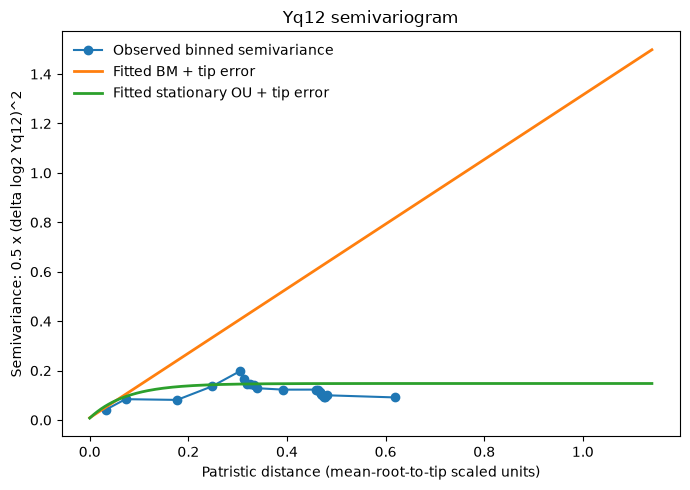

Stationary-OU implied semivariogram plateau: 0.14786607565254528


In [26]:
def build_lca_index(tree_obj):
    """Create a binary-lifting LCA index for fast patristic distances."""
    nodes = list(tree_obj.find_clades(order="preorder"))
    idx = {id(node): i for i, node in enumerate(nodes)}
    n = len(nodes)
    parent = np.full(n, -1, dtype=int)
    level = np.zeros(n, dtype=int)
    depth = np.zeros(n, dtype=float)

    for node in nodes:
        p = idx[id(node)]
        for child in node.clades:
            c = idx[id(child)]
            parent[c] = p
            level[c] = level[p] + 1
            depth[c] = depth[p] + float(child.branch_length)

    max_log = int(np.ceil(np.log2(max(2, n)))) + 1
    up = np.empty((max_log, n), dtype=int)
    up[0] = np.where(parent < 0, np.arange(n), parent)
    for k in range(1, max_log):
        up[k] = up[k - 1, up[k - 1]]

    tip_node_index = {
        node.name: idx[id(node)]
        for node in nodes
        if node.is_terminal()
    }
    return {"nodes": nodes, "up": up, "level": level, "depth": depth, "tip_index": tip_node_index}


def lca_vectorized(u, v, up, level):
    u = np.asarray(u, dtype=int).copy()
    v = np.asarray(v, dtype=int).copy()

    swap = level[u] < level[v]
    if np.any(swap):
        tmp = u[swap].copy()
        u[swap] = v[swap]
        v[swap] = tmp

    diff = level[u] - level[v]
    for k in range(up.shape[0]):
        mask = ((diff >> k) & 1).astype(bool)
        if np.any(mask):
            u[mask] = up[k, u[mask]]

    same = u == v
    for k in range(up.shape[0] - 1, -1, -1):
        mask = (~same) & (up[k, u] != up[k, v])
        if np.any(mask):
            u[mask] = up[k, u[mask]]
            v[mask] = up[k, v[mask]]

    return np.where(same, u, up[0, u])


lca_index = build_lca_index(tree_mean_reversion)
semivar_tip_names = size_tip_order
semivar_y = size_trait.loc[semivar_tip_names].to_numpy(dtype=float)
semivar_node_idx = np.array([
    lca_index["tip_index"][name]
    for name in semivar_tip_names
], dtype=int)

n_tips_semivar = len(semivar_tip_names)
pair_i_all, pair_j_all = np.triu_indices(n_tips_semivar, k=1)
n_all_pairs = len(pair_i_all)

rng_semivar = np.random.default_rng(SEMIVARIOGRAM_RANDOM_SEED)
if n_all_pairs > SEMIVARIOGRAM_MAX_PAIRS:
    keep = rng_semivar.choice(
        n_all_pairs,
        size=SEMIVARIOGRAM_MAX_PAIRS,
        replace=False,
    )
    pair_i = pair_i_all[keep]
    pair_j = pair_j_all[keep]
else:
    pair_i, pair_j = pair_i_all, pair_j_all

u = semivar_node_idx[pair_i]
v = semivar_node_idx[pair_j]
lca_nodes = lca_vectorized(u, v, lca_index["up"], lca_index["level"])
patristic = (
    lca_index["depth"][u]
    + lca_index["depth"][v]
    - 2.0 * lca_index["depth"][lca_nodes]
)
empirical_semivariance = 0.5 * (semivar_y[pair_i] - semivar_y[pair_j]) ** 2

semivar_pairs = pd.DataFrame({
    "patristic_distance": patristic,
    "semivariance": empirical_semivariance,
})
semivar_pairs["distance_bin"] = pd.qcut(
    semivar_pairs["patristic_distance"],
    q=SEMIVARIOGRAM_N_BINS,
    duplicates="drop",
)

semivariogram_binned = (
    semivar_pairs
    .groupby("distance_bin", observed=True)
    .agg(
        N_pairs=("semivariance", "size"),
        mean_patristic_distance=("patristic_distance", "mean"),
        median_patristic_distance=("patristic_distance", "median"),
        mean_semivariance=("semivariance", "mean"),
        median_semivariance=("semivariance", "median"),
    )
    .reset_index(drop=True)
)

# Model-implied semivariograms on the same scaled branch-length units.
d_grid = np.linspace(0.0, float(np.max(patristic)), 300)

bm_semivar_curve = (
    0.5 * size_bm_fit["process_variance"] * d_grid
    + size_bm_fit["tip_residual_variance"]
)

ou_stationary_var = size_ou_stationary_fit["stationary_process_variance"]
ou_semivar_curve = (
    ou_stationary_var
    * (1.0 - np.exp(-size_ou_stationary_fit["alpha"] * d_grid))
    + size_ou_stationary_fit["tip_residual_variance"]
)

semivariogram_binned.to_csv(
    OUTPUT_DIR / "Yq12_semivariogram_binned.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.plot(
    semivariogram_binned["mean_patristic_distance"],
    semivariogram_binned["mean_semivariance"],
    marker="o",
    linewidth=1.5,
    label="Observed binned semivariance",
)
ax.plot(d_grid, bm_semivar_curve, linewidth=2.0, label="Fitted BM + tip error")
ax.plot(d_grid, ou_semivar_curve, linewidth=2.0, label="Fitted stationary OU + tip error")
ax.set_xlabel("Patristic distance (mean-root-to-tip scaled units)")
ax.set_ylabel("Semivariance: 0.5 x (delta log2 Yq12)^2")
ax.set_title("Yq12 semivariogram")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Yq12_semivariogram_BM_OU.pdf", bbox_inches="tight")
plt.show()

print("Stationary-OU implied semivariogram plateau:", ou_stationary_var + size_ou_stationary_fit["tip_residual_variance"])


## 20. Alternative evolutionary models with the same tip-error structure

Test several specific alternatives to the interpretation that OU is uniquely required.

1. **Pagel's λ BM:** scales shared internal covariance while keeping each tip's total root-to-tip variance unchanged. `λ=1` recovers the original BM covariance; `λ→0` removes most phylogenetic covariance.
2. **Early-burst BM:** the process rate changes as `exp(r × depth from root)`; `r=0` is BM and `r<0` places more variance early in the tree.
3. **Two-epoch BM:** a deliberately simple rate-heterogeneous BM in which deep and recent branches can have different process rates. Three prespecified breakpoints are shown (25%, 50%, 75% of mean tree depth).

All models retain `τ²` tip residual variance, and all are compared on the same tips.

In [27]:
def build_pruning_branch_metadata(tree_obj, tree_data):
    """Map pruning-array entries to root depths and parent depths."""
    node_to_post = {id(node): i for i, node in enumerate(tree_data["nodes"])}
    n = len(tree_data["nodes"])
    parent_depth = np.zeros(n, dtype=float)
    node_depth = np.zeros(n, dtype=float)

    for parent in tree_obj.find_clades(order="preorder"):
        p_idx = node_to_post[id(parent)]
        for child in parent.clades:
            c_idx = node_to_post[id(child)]
            parent_depth[c_idx] = node_depth[p_idx]
            node_depth[c_idx] = node_depth[p_idx] + float(child.branch_length)

    return {
        "parent_depth": parent_depth,
        "node_depth": node_depth,
        "is_tip": np.asarray(tree_data["is_tip"], dtype=bool),
        "base_branch_length": np.asarray(tree_data["branch_length"], dtype=float),
    }


branch_meta = build_pruning_branch_metadata(tree_mean_reversion, size_pruning_tree)


def fit_pagel_lambda_bm(tree_data, y_values, branch_meta):
    y = np.asarray(y_values, dtype=float)
    trait_var = float(np.var(y, ddof=1))
    log_sigma_bounds = (np.log(trait_var * 1e-4), np.log(trait_var * 1e4))
    log_tau_bounds = (np.log(trait_var * 1e-8), np.log(trait_var * 10.0))
    bounds = [log_sigma_bounds, log_tau_bounds, PAGEL_LAMBDA_BOUNDS]

    base = branch_meta["base_branch_length"]
    is_tip = branch_meta["is_tip"]
    parent_depth = branch_meta["parent_depth"]

    def transformed_lengths(lam):
        out = base.copy()
        internal = (~is_tip) & (np.arange(len(base)) != tree_data["root_index"])
        out[internal] = lam * base[internal]
        terminal = is_tip
        out[terminal] = base[terminal] + (1.0 - lam) * parent_depth[terminal]
        return out

    def objective(par):
        sigma2 = np.exp(par[0])
        tau2 = np.exp(par[1])
        lam = float(par[2])
        td = _tree_data_with_branch_lengths(tree_data, transformed_lengths(lam))
        ll = tree_process_profile_loglik(
            td,
            process_variance=sigma2,
            tip_residual_variance=tau2,
            model="BM",
        )["logLik"]
        return 1e300 if not np.isfinite(ll) else -ll

    starts = []
    for lam0 in (0.05, 0.20, 0.50, 0.90, 1.0):
        for frac in (0.01, 0.10):
            starts.append(np.array([
                np.log(trait_var),
                np.log(max(trait_var * frac, trait_var * 1e-8)),
                lam0,
            ]))

    fits = []
    for start in starts:
        result = minimize(
            objective,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 1000, "ftol": 1e-11, "gtol": 1e-7},
        )
        if result.success and np.isfinite(result.fun):
            fits.append(result)
    if not fits:
        raise RuntimeError("Pagel-lambda BM did not converge.")

    best = min(fits, key=lambda z: z.fun)
    sigma2, tau2, lam = np.exp(best.x[0]), np.exp(best.x[1]), float(best.x[2])
    td = _tree_data_with_branch_lengths(tree_data, transformed_lengths(lam))
    ll_obj = tree_process_profile_loglik(td, sigma2, tau2, model="BM")
    k = 4  # sigma2 + tau2 + lambda + profiled root state
    return {
        "model": "Pagel_lambda_BM",
        "logLik": float(ll_obj["logLik"]),
        "n_parameters": k,
        "AIC": 2*k - 2*ll_obj["logLik"],
        "lambda": lam,
        "lambda_at_boundary": bool(
            np.isclose(lam, PAGEL_LAMBDA_BOUNDS[0], rtol=0, atol=1e-5)
            or np.isclose(lam, PAGEL_LAMBDA_BOUNDS[1], rtol=0, atol=1e-5)
        ),
        "process_variance": float(sigma2),
        "tip_residual_variance": float(tau2),
        "root_state_ML": float(ll_obj["root_state_ML"]),
    }


def fit_early_burst_bm(tree_data, y_values, branch_meta):
    y = np.asarray(y_values, dtype=float)
    trait_var = float(np.var(y, ddof=1))
    log_sigma_bounds = (np.log(trait_var * 1e-4), np.log(trait_var * 1e4))
    log_tau_bounds = (np.log(trait_var * 1e-8), np.log(trait_var * 10.0))
    bounds = [log_sigma_bounds, log_tau_bounds, EARLY_BURST_R_BOUNDS]

    parent_depth = branch_meta["parent_depth"]
    child_depth = branch_meta["node_depth"]
    root_index = tree_data["root_index"]

    def eb_lengths(r):
        if abs(r) < 1e-8:
            out = branch_meta["base_branch_length"].copy()
        else:
            out = (np.exp(r * child_depth) - np.exp(r * parent_depth)) / r
        out[root_index] = 0.0
        return np.maximum(out, 0.0)

    def objective(par):
        sigma2 = np.exp(par[0])
        tau2 = np.exp(par[1])
        r = float(par[2])
        td = _tree_data_with_branch_lengths(tree_data, eb_lengths(r))
        ll = tree_process_profile_loglik(td, sigma2, tau2, model="BM")["logLik"]
        return 1e300 if not np.isfinite(ll) else -ll

    starts = []
    for r0 in (-10.0, -3.0, -1.0, -0.1, 0.0):
        for frac in (0.01, 0.10):
            starts.append(np.array([
                np.log(trait_var),
                np.log(max(trait_var * frac, trait_var * 1e-8)),
                r0,
            ]))

    fits = []
    for start in starts:
        result = minimize(
            objective,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 1000, "ftol": 1e-11, "gtol": 1e-7},
        )
        if result.success and np.isfinite(result.fun):
            fits.append(result)
    if not fits:
        raise RuntimeError("Early-burst BM did not converge.")

    best = min(fits, key=lambda z: z.fun)
    sigma2, tau2, r = np.exp(best.x[0]), np.exp(best.x[1]), float(best.x[2])
    td = _tree_data_with_branch_lengths(tree_data, eb_lengths(r))
    ll_obj = tree_process_profile_loglik(td, sigma2, tau2, model="BM")
    k = 4  # sigma2 + tau2 + r + profiled root state
    return {
        "model": "Early_burst_BM",
        "logLik": float(ll_obj["logLik"]),
        "n_parameters": k,
        "AIC": 2*k - 2*ll_obj["logLik"],
        "EB_r": r,
        "EB_r_at_boundary": bool(
            np.isclose(r, EARLY_BURST_R_BOUNDS[0], rtol=0, atol=1e-3)
            or np.isclose(r, EARLY_BURST_R_BOUNDS[1], rtol=0, atol=1e-5)
        ),
        "process_variance": float(sigma2),
        "tip_residual_variance": float(tau2),
        "root_state_ML": float(ll_obj["root_state_ML"]),
    }


def fit_two_epoch_bm(tree_data, y_values, branch_meta, break_fraction):
    """
    Two-rate BM with a fixed breakpoint in root-depth units.
    process_variance is the deep rate; recent_rate_ratio multiplies it.
    """
    y = np.asarray(y_values, dtype=float)
    trait_var = float(np.var(y, ddof=1))
    log_sigma_bounds = (np.log(trait_var * 1e-4), np.log(trait_var * 1e4))
    log_tau_bounds = (np.log(trait_var * 1e-8), np.log(trait_var * 10.0))
    log_ratio_bounds = (np.log(1e-3), np.log(1e3))
    bounds = [log_sigma_bounds, log_tau_bounds, log_ratio_bounds]

    # The scaled tree has mean root-to-tip ~1; retain explicit calculation.
    tip_depths = branch_meta["node_depth"][branch_meta["is_tip"]]
    breakpoint = float(break_fraction * np.mean(tip_depths))
    p = branch_meta["parent_depth"]
    c = branch_meta["node_depth"]
    root_index = tree_data["root_index"]

    deep_len = np.maximum(0.0, np.minimum(c, breakpoint) - p)
    recent_len = np.maximum(0.0, c - np.maximum(p, breakpoint))
    deep_len[root_index] = 0.0
    recent_len[root_index] = 0.0

    def effective_lengths(rate_ratio):
        return deep_len + rate_ratio * recent_len

    def objective(par):
        sigma2 = np.exp(par[0])
        tau2 = np.exp(par[1])
        ratio = np.exp(par[2])
        td = _tree_data_with_branch_lengths(tree_data, effective_lengths(ratio))
        ll = tree_process_profile_loglik(td, sigma2, tau2, model="BM")["logLik"]
        return 1e300 if not np.isfinite(ll) else -ll

    starts = []
    for ratio0 in (0.1, 1.0, 10.0):
        for frac in (0.01, 0.10):
            starts.append(np.array([
                np.log(trait_var),
                np.log(max(trait_var * frac, trait_var * 1e-8)),
                np.log(ratio0),
            ]))

    fits = []
    for start in starts:
        result = minimize(
            objective,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 1000, "ftol": 1e-11, "gtol": 1e-7},
        )
        if result.success and np.isfinite(result.fun):
            fits.append(result)
    if not fits:
        raise RuntimeError(f"Two-epoch BM did not converge at break {break_fraction}.")

    best = min(fits, key=lambda z: z.fun)
    sigma2 = float(np.exp(best.x[0]))
    tau2 = float(np.exp(best.x[1]))
    ratio = float(np.exp(best.x[2]))
    td = _tree_data_with_branch_lengths(tree_data, effective_lengths(ratio))
    ll_obj = tree_process_profile_loglik(td, sigma2, tau2, model="BM")
    k = 4  # deep rate + rate ratio + tau2 + profiled root state; breakpoint fixed a priori
    return {
        "model": f"Two_epoch_BM_break_{break_fraction:.2f}",
        "logLik": float(ll_obj["logLik"]),
        "n_parameters": k,
        "AIC": 2*k - 2*ll_obj["logLik"],
        "break_fraction": float(break_fraction),
        "break_depth_scaled": breakpoint,
        "recent_to_deep_rate_ratio": ratio,
        "rate_ratio_at_boundary": bool(
            ratio <= 1.001e-3 or ratio >= 0.999e3
        ),
        "deep_process_variance": sigma2,
        "recent_process_variance": sigma2 * ratio,
        "tip_residual_variance": tau2,
        "root_state_ML": float(ll_obj["root_state_ML"]),
    }


print("Fitting Pagel-lambda BM...")
pagel_lambda_fit = fit_pagel_lambda_bm(size_pruning_tree, size_values, branch_meta)

print("Fitting early-burst BM...")
early_burst_fit = fit_early_burst_bm(size_pruning_tree, size_values, branch_meta)

print("Fitting prespecified two-epoch BM alternatives...")
two_epoch_fits = [
    fit_two_epoch_bm(size_pruning_tree, size_values, branch_meta, frac)
    for frac in TWO_EPOCH_BREAK_FRACTIONS
]


def model_row(name, fit):
    k = int(fit["n_parameters"])
    ll = float(fit["logLik"])
    return {
        "model": name,
        "logLik": ll,
        "k": k,
        "AIC": 2*k - 2*ll,
        "AICc": aicc_from_loglik(ll, k, len(size_values)),
    }

model_rows = [
    model_row("BM_single_rate", size_bm_fit),
    model_row("Pagel_lambda_BM", pagel_lambda_fit),
    model_row("Early_burst_BM", early_burst_fit),
]
model_rows.extend(model_row(fit["model"], fit) for fit in two_epoch_fits)
model_rows.extend([
    model_row("OU_stationary", size_ou_stationary_fit),
    model_row("OU_nonstationary", size_ou_nonstationary_fit),
])

alternative_model_comparison = pd.DataFrame(model_rows)
alternative_model_comparison["Delta_AICc"] = (
    alternative_model_comparison["AICc"]
    - alternative_model_comparison["AICc"].min()
)
relative_lik = np.exp(-0.5 * alternative_model_comparison["Delta_AICc"])
alternative_model_comparison["Akaike_weight_AICc"] = relative_lik / relative_lik.sum()
alternative_model_comparison = alternative_model_comparison.sort_values("AICc").reset_index(drop=True)

display(alternative_model_comparison)
print("\nPagel lambda fit:")
display(pd.Series(pagel_lambda_fit).to_frame("value"))
print("\nEarly-burst fit:")
display(pd.Series(early_burst_fit).to_frame("value"))
print("\nTwo-epoch fits:")
display(pd.DataFrame(two_epoch_fits))

alternative_model_comparison.to_csv(
    OUTPUT_DIR / "Yq12_alternative_model_comparison_AICc.csv",
    index=False,
)
pd.Series(pagel_lambda_fit).to_frame("value").to_csv(
    OUTPUT_DIR / "Yq12_Pagel_lambda_BM_fit.csv"
)
pd.Series(early_burst_fit).to_frame("value").to_csv(
    OUTPUT_DIR / "Yq12_early_burst_BM_fit.csv"
)
pd.DataFrame(two_epoch_fits).to_csv(
    OUTPUT_DIR / "Yq12_two_epoch_BM_fits.csv",
    index=False,
)


Fitting Pagel-lambda BM...
Fitting early-burst BM...
Fitting prespecified two-epoch BM alternatives...


,model,logLik,k,AIC,AICc,Delta_AICc,Akaike_weight_AICc
0,OU_nonstationary,150.810650,5,-291.621300,-291.583421,0.000000,5.493808e-01
1,OU_stationary,149.606160,4,-291.212320,-291.187083,0.396338,4.506192e-01
2,Two_epoch_BM_break_0.75,121.323003,4,-234.646007,-234.620770,56.962651,2.347421e-13
3,Two_epoch_BM_break_0.25,120.196395,4,-232.392790,-232.367553,59.215868,7.608712e-14
4,Two_epoch_BM_break_0.50,120.176255,4,-232.352510,-232.327274,59.256148,7.457006e-14
5,BM_single_rate,117.976742,3,-229.953484,-229.938351,61.645070,2.258482e-14
6,Pagel_lambda_BM,118.290797,4,-228.581594,-228.556358,63.027064,1.131672e-14
7,Early_burst_BM,117.976742,4,-227.953484,-227.928247,63.655174,8.266621e-15



Pagel lambda fit:


,value
model,Pagel_lambda_BM
logLik,118.290797
n_parameters,4
AIC,-228.581594
lambda,0.997358
lambda_at_boundary,False
process_variance,2.616567
tip_residual_variance,0.002279
root_state_ML,24.207144



Early-burst fit:


,value
model,Early_burst_BM
logLik,117.976742
n_parameters,4
AIC,-227.953484
EB_r,0.0
EB_r_at_boundary,True
process_variance,2.612444
tip_residual_variance,0.009178
root_state_ML,24.208822



Two-epoch fits:


,model,logLik,n_parameters,AIC,break_fraction,break_depth_scaled,recent_to_deep_rate_ratio,rate_ratio_at_boundary,deep_process_variance,recent_process_variance,tip_residual_variance,root_state_ML
0,Two_epoch_BM_break_0.25,120.196395,4,-232.392790,0.25,0.25,999.838502,True,0.002622,2.621556,0.009130,24.086896
1,Two_epoch_BM_break_0.50,120.176255,4,-232.352510,0.50,0.50,17.923486,False,0.146236,2.621054,0.009156,24.206495
2,Two_epoch_BM_break_0.75,121.323003,4,-234.646007,0.75,0.75,18.823252,False,0.139374,2.623480,0.009152,24.227967


## 21. Topology-only ultrametric branch-length sensitivity

In [28]:
def make_grafen_ultrametric(tree_input, rho=1.0):
    """Topology-only Grafen-style ultrametric branch lengths with root height 1."""
    t = copy.deepcopy(tree_input)
    terminals = t.get_terminals()
    n_tips = len(terminals)
    if n_tips < 2:
        raise ValueError("Need at least two tips.")

    desc_count = {}
    for node in t.find_clades(order="postorder"):
        if node.is_terminal():
            desc_count[id(node)] = 1
        else:
            desc_count[id(node)] = sum(desc_count[id(ch)] for ch in node.clades)

    height = {}
    for node in t.find_clades(order="preorder"):
        n_desc = desc_count[id(node)]
        if node.is_terminal():
            height[id(node)] = 0.0
        else:
            height[id(node)] = ((n_desc - 1.0) / (n_tips - 1.0)) ** float(rho)

    for parent in t.find_clades(order="preorder"):
        for child in parent.clades:
            bl = height[id(parent)] - height[id(child)]
            if bl <= 0:
                raise ValueError(
                    "Grafen transform produced a non-positive branch. "
                    "Check for unary nodes/polytomy artifacts."
                )
            child.branch_length = float(bl)

    return t


grafen_tree = make_grafen_ultrametric(tree, rho=GRAFEN_RHO)
grafen_root_to_tip = np.array([
    grafen_tree.distance(grafen_tree.root, tip)
    for tip in grafen_tree.get_terminals()
])

print(
    "Grafen root-to-tip mean / SD:",
    float(grafen_root_to_tip.mean()),
    float(grafen_root_to_tip.std(ddof=1)),
)

grafen_summary = fit_size_model_set_for_tree(
    grafen_tree,
    label="Grafen_topology_only_ultrametric",
)

branch_length_sensitivity = pd.DataFrame([
    primary_root_summary,
    grafen_summary,
])

display(branch_length_sensitivity)
branch_length_sensitivity.to_csv(
    OUTPUT_DIR / "Yq12_branch_length_sensitivity_Grafen.csv",
    index=False,
)


Grafen root-to-tip mean / SD: 1.0 0.0


,rooting,N,time_scale_original_tree,BM_AIC,OU_nonstationary_AIC,OU_stationary_AIC,DeltaAIC_BM_minus_nonstationary_OU,DeltaAIC_BM_minus_stationary_OU,nonstationary_optimum_Yq12_Mb,stationary_optimum_Yq12_Mb,nonstationary_alpha,stationary_alpha,nonstationary_half_life_scaled,stationary_half_life_scaled
0,HG01890_outgroup_edge,1590,0.033844,-229.953484,-291.621300,-291.212320,61.667817,61.258836,26.407956,26.236781,13.537323,13.374932,0.051203,0.051824
1,Grafen_topology_only_ultrametric,1590,1.000000,376.461287,254.258316,252.258316,122.202970,124.202971,28.320612,25.396709,50.687899,50.694944,0.013675,0.013673


## 22. Short-branch process variance versus tip residual variance

In [29]:
scaled_positive_branches = np.asarray([
    clade.branch_length
    for clade in tree_mean_reversion.find_clades(order="preorder")
    if clade is not tree_mean_reversion.root
    and clade.branch_length is not None
    and clade.branch_length > 0
], dtype=float)

median_short_branch = float(np.median(scaled_positive_branches))
alpha_hat = float(size_ou_stationary_fit["alpha"])
sigma2_hat = float(size_ou_stationary_fit["process_variance"])
tau2_hat = float(size_ou_stationary_fit["tip_residual_variance"])

ou_transition_var_median_branch = (
    sigma2_hat
    * (-np.expm1(-2.0 * alpha_hat * median_short_branch))
    / (2.0 * alpha_hat)
)

short_branch_identifiability = pd.Series({
    "median_positive_branch_scaled": median_short_branch,
    "OU_transition_variance_at_median_branch": ou_transition_var_median_branch,
    "tip_residual_variance_tau2": tau2_hat,
    "transition_variance_to_tau2_ratio": ou_transition_var_median_branch / tau2_hat,
})

display(short_branch_identifiability.to_frame("value"))
short_branch_identifiability.to_frame("value").to_csv(
    OUTPUT_DIR / "Yq12_tau2_short_branch_identifiability.csv"
)


,value
median_positive_branch_scaled,0.002978
OU_transition_variance_at_median_branch,0.010717
tip_residual_variance_tau2,0.007919
transition_variance_to_tau2_ratio,1.353400


## 23. Optional drop-one-haplogroup sensitivity

In [30]:
def drop_one_haplogroup_refits():
    rows = []
    group_counts = traits["YHaploBroad"].value_counts(dropna=False)

    groups = [
        g for g, n in group_counts.items()
        if pd.notna(g) and int(n) >= DROP_ONE_HAPLOGROUP_MIN_N
    ]

    for group in groups:
        excluded_samples = set(
            traits.index[traits["YHaploBroad"].eq(group)]
        )
        keep_samples = set(size_trait.index) - excluded_samples

        t = copy.deepcopy(tree)
        for tip in list(t.get_terminals()):
            if tip.name not in keep_samples:
                t.prune(tip)

        scaled_t, scale_t = scale_tree_to_mean_root_tip_one(t)
        local_order = [tip.name for tip in scaled_t.get_terminals()]
        local_trait = size_trait.loc[local_order]
        local_y = local_trait.to_numpy(dtype=float)
        local_pruning = prepare_pruning_tree(scaled_t, local_trait)

        bm = fit_mean_reversion_model(local_pruning, local_y, model="BM")

        global OU_TIME_SCALE
        old_scale = OU_TIME_SCALE
        OU_TIME_SCALE = scale_t
        try:
            ou = fit_stationary_ou_model(local_pruning, local_y, theta_fixed=None)
        finally:
            OU_TIME_SCALE = old_scale

        rows.append({
            "excluded_haplogroup": group,
            "excluded_N": len(excluded_samples),
            "remaining_N": len(local_y),
            "BM_AIC": bm["AIC"],
            "OU_stationary_AIC": ou["AIC"],
            "DeltaAIC_BM_minus_OU": bm["AIC"] - ou["AIC"],
            "OU_theta_log2": ou["theta"],
            "OU_optimum_Yq12_Mb": 2.0 ** ou["theta"] / 1e6,
            "OU_alpha_scaled": ou["alpha"],
            "OU_half_life_original_tree_units": ou["half_life_original_tree_units"],
            "OU_tip_residual_variance": ou["tip_residual_variance"],
        })

    return pd.DataFrame(rows).sort_values("DeltaAIC_BM_minus_OU")


if RUN_DROP_ONE_HAPLOGROUP:
    drop_one_haplogroup = drop_one_haplogroup_refits()
    display(drop_one_haplogroup)
    drop_one_haplogroup.to_csv(
        OUTPUT_DIR / "Yq12_drop_one_haplogroup_sensitivity.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(8.0, max(4.5, 0.28 * len(drop_one_haplogroup))))
    plot_df = drop_one_haplogroup.sort_values("DeltaAIC_BM_minus_OU")
    ax.barh(plot_df["excluded_haplogroup"].astype(str), plot_df["DeltaAIC_BM_minus_OU"])
    ax.axvline(0.0, linewidth=1.0)
    ax.set_xlabel("Delta AIC = BM - stationary OU")
    ax.set_ylabel("Excluded broad haplogroup")
    ax.set_title("Drop-one-haplogroup sensitivity")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Yq12_drop_one_haplogroup_sensitivity.pdf", bbox_inches="tight")
    plt.show()
else:
    print("RUN_DROP_ONE_HAPLOGROUP=False; optional sensitivity not run.")


RUN_DROP_ONE_HAPLOGROUP=False; optional sensitivity not run.
